# Private Equity and Private Credit Cross-Dealing Analysis

Large investment firms often wear two hats at the same time: the **private equity (PE)** arm buys companies, improves them, and sells them later; the **private credit (PC)** arm lends money to companies in exchange for interest payments. Many major financial groups have both arms operating under the same roof.

This analysis asks a straightforward question: **when a PE firm's portfolio company borrows money from a lender that has a prior financial relationship with the PE sponsor, does it pay a different interest rate than it would from a completely unrelated lender?**

We examine two datasets:
- **Atlas** — 315,238 individual deal records across 112,276 companies, covering buyouts, loans, IPOs, and exits
- **Summit** — 48,317 investment records from fund managers, each with entry financials and eventual returns

The nine steps that follow load and clean these datasets, reconstruct which PE firm owned each company at the time of each loan, classify the lender–sponsor relationship, test whether relationship type affects pricing, and compare financial outcomes across relationship types.


---
# Step 1 — Load and Verify Both Datasets

## 1-A  Install Software Tools

Three external libraries are installed:
- **`rapidfuzz`** — quickly finds similar company names even when spelling differs slightly (used in Step 7)
- **`statsmodels`** — runs statistical regressions (used in Step 6)
- **`gdown`** — downloads files from Google Drive


In [94]:
!pip install rapidfuzz statsmodels gdown --quiet

In [95]:
import re
import difflib
import gdown
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from rapidfuzz import fuzz, process

print("All libraries imported successfully.")

All libraries imported successfully.


In [96]:
# Replace with your actual atlas public file ID
atlas_file_id = '1fE4cLzNUyfjSumMhbTKAlPpUtdyLoPYd'
atlas_url = f'https://drive.google.com/uc?export=download&id={atlas_file_id}'
# Replace with your actual summit public file ID
summit_file_id = "1kUJQxZgEmtY4bzUFd43UWvbbITokFVdE"
summit_url = f'https://drive.google.com/uc?export=download&id={summit_file_id}'
# Download the files locally
print("Downloading Atlas...")
gdown.download(atlas_url, 'atlas.csv', quiet=False)

print("Downloading Summit...")
gdown.download(summit_url, 'summit.csv', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1fE4cLzNUyfjSumMhbTKAlPpUtdyLoPYd
From (redirected): https://drive.google.com/uc?export=download&id=1fE4cLzNUyfjSumMhbTKAlPpUtdyLoPYd&confirm=t&uuid=e021b37d-2dbd-46bd-bc1f-6da0c62abbcd
To: /content/atlas.csv
100%|██████████| 177M/177M [00:00<00:00, 183MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1kUJQxZgEmtY4bzUFd43UWvbbITokFVdE
To: /content/summit.csv
100%|██████████| 27.4M/27.4M [00:00<00:00, 83.5MB/s]


'summit.csv'

## 1-B  Record the File Paths

The two datasets are saved locally after downloading. Their paths are stored in two variables (`ATLAS_PATH` and `SUMMIT_PATH`) so every later step finds the right file without repeating the location string.


In [97]:
ATLAS_PATH  = "/content/atlas.csv"
SUMMIT_PATH = "/content/summit.csv"
print(f"Atlas  : {ATLAS_PATH}")
print(f"Summit : {SUMMIT_PATH}")

Atlas  : /content/atlas.csv
Summit : /content/summit.csv


## 1-C  Declare Column Types for Atlas

The Atlas file has 89 columns. If Python is left to guess their types automatically, it can make mistakes — for example, reading a column of numbers as plain text, which would silently break any arithmetic later.

This cell explicitly declares the correct type for all 84 non-date columns:
- **Text** (`str`): IDs, names, category labels, descriptions
- **Whole numbers** (`Int64`): deal sequence number, employee count, fiscal year — `Int64` (capital I) is used instead of plain `int` because it can hold blank values without crashing
- **Decimal numbers** (`float`): all financial amounts, ratios, and valuations

The five date columns (`DealDate`, `AnnouncedDate`, `OriginalRegistrationDate`, `CurrentRegistrationDate`, `LastUpdated`) are handled separately by `parse_dates` in the loading step.

**Output:** The dictionary contains **84 column entries**.


In [98]:
atlas_str_cols = [
    'CompanyID','CompanyName','DealID','DealStatus','DealSizeStatus',
    'VCRound','VCRoundUp_Down_Flat','StockSplit','DealType','DealType2',
    'DealType3','DealClass','DealSynopsis','NativeCurrencyOfDeal',
    'AddOn','AddOnSponsors','AddOnPlatform','Debts','BusinessStatus',
    'FinancingStatus','SiteLocation','PostValuationStatus',
    'CEOPBId','CEO','CEOPhone','CEOEmail','CEOBiography','CEOEducation',
    'TickerSymbol','Exchange','RowID','EquitySponsorName','CreditProviderName',
    'Investors','NewInvestors','FollowOnInvestors',
]
atlas_int_cols   = {'DealNo':'Int64','Employees':'Int64','FiscalYear':'Int64'}
atlas_float_cols = [
    'DealSize','NativeAmountOfDeal','PercentAcquired','RaisedToDate',
    'TotalInvestedCapital','InvestorOwnership','TotalInvestedEquity',
    'TotalNewDebt','DebtRaisedInRound','ContingentPayout',
    'PremoneyValuation','PostValuation',
    'FilIngRangeLow','FilIngRangeHigh','NumberOfShares',
    'MarketCapEndOfFirstTradIngDay',
    'Price1DayAfterOfferIng','Price5DaysAfterOfferIng','Price30DaysAfterOfferIng',
    'ImpliedEV','Revenue','RevenueGrowthSinceLastDebtDeal',
    'GrossProfit','NetIncome','EBITDA','TotalDebt',
    'Debt_EBITDA','Debt_Equity',
    'DealSize_EBITDA','Valuation_EBITDA','ImpliedEV_EBITDA',
    'ImpliedEV_EBIT','Valuation_EBIT','Valuation_NetIncome',
    'DealSize_EBIT','DealSize_NetIncome','DealSize_Revenue',
    'Valuation_Revenue','ImpliedEV_Revenue',
    'DealSize_CashFlow','Valuation_CashFlow','ImpliedEV_CashFlow',
    'ImpliedEV_NetIncome','EBITDAMarginPercent','LoanSpreadBps',
]
atlas_dtypes = {col: str   for col in atlas_str_cols}
atlas_dtypes.update(atlas_int_cols)
atlas_dtypes.update({col: float for col in atlas_float_cols})
atlas_date_cols = ['DealDate','AnnouncedDate','OriginalRegistrationDate',
                   'CurrentRegistrationDate','LastUpdated']
print(f"dtype dict has {len(atlas_dtypes)} column entries.")

dtype dict has 84 column entries.


## 1-D  Load Atlas Into Memory

Atlas is read from the CSV file using the type dictionary just defined. The raw file is stored in `atlas_raw` and never changed — all subsequent work uses a copy called `atlas`.

**Result: 315,238 rows × 89 columns, using approximately 215 MB of memory.**


In [99]:
atlas_raw = pd.read_csv(ATLAS_PATH, dtype=atlas_dtypes, parse_dates=atlas_date_cols)
print(f'Atlas loaded: {atlas_raw.shape[0]:,} rows x {atlas_raw.shape[1]} columns')
atlas_raw.info(verbose=False, show_counts=True)

Atlas loaded: 315,238 rows x 89 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315238 entries, 0 to 315237
Columns: 89 entries, CompanyID to LoanSpreadBps
dtypes: Int64(3), datetime64[ns](5), float64(45), object(36)
memory usage: 215.0+ MB


## 1-E  Verify Atlas Date Columns

Even with `parse_dates` specified, a date column can silently stay as plain text if a single value is formatted unusually. This cell re-applies date parsing with `errors='coerce'`, which converts any unreadable value to a blank (`NaT`) instead of raising an error, and then prints the status of each date column.

**Results:**
- `DealDate` — all 315,238 values present and correctly parsed as dates ✓
- `AnnouncedDate` — all 315,238 values present and correctly parsed ✓
- `OriginalRegistrationDate` — entirely blank (all 315,238 are null); this field is not populated in Atlas and will not be used
- `CurrentRegistrationDate` — same, entirely blank
- `LastUpdated` — all values present and correctly parsed ✓


In [100]:
atlas = atlas_raw.copy()
for col in atlas_date_cols:
    atlas[col] = pd.to_datetime(atlas[col], errors='coerce')

print("--- Atlas date dtypes after coerce ---")
for col in atlas_date_cols:
    dtype  = atlas[col].dtype
    n_null = atlas[col].isna().sum()
    status = "OK" if str(dtype).startswith("datetime") else "PROBLEM"
    print(f"  [{status}] {col:<35} dtype={dtype}   nulls={n_null:,}")

--- Atlas date dtypes after coerce ---
  [OK] DealDate                            dtype=datetime64[ns]   nulls=0
  [OK] AnnouncedDate                       dtype=datetime64[ns]   nulls=0
  [OK] OriginalRegistrationDate            dtype=datetime64[ns]   nulls=315,238
  [OK] CurrentRegistrationDate             dtype=datetime64[ns]   nulls=315,238
  [OK] LastUpdated                         dtype=datetime64[ns]   nulls=0


## 1-F  Declare Column Types and Load Summit

The same type-declaration approach is applied to Summit's 58 columns before reading the file. Summit contains fund-level performance data: which firm invested, in which company, at what valuation, and with what eventual return.

**Result: 48,317 rows × 58 columns.**


In [101]:
summit_str_cols = [
    'GP_Name','GP_Asset_Class','Company_Name','investment_currency',
    'import_id','gp_id','fund_id','entity_id','entity_type_id',
    'GP_Sector','GP_Sub_Sector','Fund_Name','Fund_Vintage','Fund_Size_USD',
    'Fund_Size_Local','Fund_Currency','Fund_Currency_FX','Fund_Asset_Class',
    'Fund_Sector','Fund_Sub_Sector','Fund_Industry_Focus',
    'GICS_Sector','GICS_SubSector','Company_Country','Company_Region',
    'ciq_company_id','investment_name','security_name','security_type',
    'report_date','total_value','losses','import_has_cashflow',
    'entry_opmetric_date','entry_ownership_percentage',
    'exit_current_opmetric_date','exit_current_ownership_percentage',
    'company_status',
]
summit_int_cols   = {'performance_id':'Int64','investment_id':'Int64'}
summit_float_cols = [
    'invested','realized','unrealized','gross_tvm','gross_irr',
    'entry_revenue','entry_ebitda','entry_tev','entry_netdebt',
    'exit_current_revenue','exit_current_ebitda',
    'exit_current_tev','exit_current_netdebt',
    'loss_multiple','default_flag',
]
summit_dtypes = {col: str for col in summit_str_cols}
summit_dtypes.update(summit_int_cols)
summit_dtypes.update({col: float for col in summit_float_cols})
summit_date_cols = ['entry_date','exit_date']

summit_raw = pd.read_csv(SUMMIT_PATH, dtype=summit_dtypes, parse_dates=summit_date_cols)
print(f"Summit loaded: {summit_raw.shape[0]:,} rows x {summit_raw.shape[1]} columns")

Summit loaded: 48,317 rows x 58 columns


## 1-G  Fix the `fully_exited` Column in Summit

Summit contains a column (`fully_exited`) that indicates whether an investment has been fully sold or closed. It was stored as the literal text strings `"True"` and `"False"` rather than as a proper true/false value. The column is converted to a real boolean type so it can be used in filters correctly.

**Result: 34,769 fully exited investments, 13,548 still active.**


In [102]:
summit = summit_raw.copy()
for col in summit_date_cols:
    summit[col] = pd.to_datetime(summit[col], errors='coerce')

summit['fully_exited'] = summit['fully_exited'].map(
    lambda x: True  if str(x).strip().lower() == 'true'  else
              False if str(x).strip().lower() == 'false' else
              np.nan
).astype('boolean')

print(f"fully_exited dtype : {summit['fully_exited'].dtype}")
print(summit['fully_exited'].value_counts(dropna=False))

fully_exited dtype : boolean
fully_exited
True     34769
False    13548
Name: count, dtype: Int64


## 1-H  Create a Single Reliable Date Column (`EffectiveDate`)

Atlas has two date fields per deal:
- `DealDate` — the actual closing date of the deal
- `AnnouncedDate` — the public announcement date, available even for deals whose final terms were never disclosed

`EffectiveDate` uses `DealDate` and falls back to `AnnouncedDate` only if `DealDate` is missing. Since `DealDate` has zero missing values in this dataset, `EffectiveDate` also has zero missing values — no rows are lost.


In [103]:
print(f"DealDate nulls before fill     : {atlas['DealDate'].isna().sum():,}")
atlas['EffectiveDate'] = atlas['DealDate'].fillna(atlas['AnnouncedDate'])
print(f"EffectiveDate nulls after fill : {atlas['EffectiveDate'].isna().sum():,}")

DealDate nulls before fill     : 0
EffectiveDate nulls after fill : 0


## 1-I  Data Quality Checks on Both Datasets

Three quick checks before any analysis:

**1. No duplicate deal IDs.** All 315,238 rows in Atlas have a unique `DealID`. If two rows shared an ID it would indicate corrupted source data.

**2. Deal type distribution.** The 315,238 deals span 21 categories. The five most common are:
- Merger/Acquisition: 48,292 deals (15.32%)
- Debt – General: 31,349 (9.94%)
- Buyout/LBO: 29,734 (9.43%)
- Early Stage VC: 25,496 (8.09%)
- Accelerator/Incubator: 23,258 (7.38%)

This distribution matters because Steps 2 and 3 focus specifically on the Buyout/LBO, Secondary Transaction, and Debt categories.

**3. Summit outcome availability.** All key outcome metrics (`gross_irr`, `gross_tvm`, `default_flag`, `loss_multiple`, `entry_revenue`, `entry_ebitda`, `entry_tev`) are confirmed present in Summit before any merging happens.


In [104]:
print("=== Atlas ===")
print(f"  Rows: {len(atlas):,}  |  Unique CompanyIDs: {atlas['CompanyID'].nunique():,}  |  Duplicate DealIDs: {atlas['DealID'].duplicated().sum():,}")
print()
print("=== Atlas DealType distribution ===")
dt  = atlas['DealType'].value_counts(dropna=False)
pct = (dt / len(atlas) * 100).round(2)
print(pd.concat([dt.rename('Count'), pct.rename('Pct')], axis=1).to_string())
print()
print("=== Summit ===")
print(f"  Rows: {len(summit):,}  |  Unique GP_Names: {summit['GP_Name'].nunique():,}")
print()
print("=== Summit outcome completeness ===")
print(summit[['gross_irr','gross_tvm','default_flag','loss_multiple',
              'entry_revenue','entry_ebitda','entry_tev']].notna().sum())

=== Atlas ===
  Rows: 315,238  |  Unique CompanyIDs: 112,276  |  Duplicate DealIDs: 0

=== Atlas DealType distribution ===
                                 Count    Pct
DealType                                     
Merger/Acquisition               48292  15.32
Debt - General                   31349   9.94
Buyout/LBO                       29734   9.43
Early Stage VC                   25496   8.09
Accelerator/Incubator            23258   7.38
Later Stage VC                   20658   6.55
Seed Round                       18402   5.84
PE Growth/Expansion              13916   4.41
Debt Refinancing                 12677   4.02
Corporate Asset Purchase         11738   3.72
Grant                            11679   3.70
Debt - PPP                       10122   3.21
Secondary Transaction - Private   9783   3.10
PIPE                              9254   2.94
Angel (individual)                9073   2.88
Debt - Acquisition                8918   2.83
IPO                               7679   2.44
Out

### Figure 1 -- Deal Type Distribution (Section 2.1)

Insert after **1-I** (cell 20). Shows the composition of all 315,238 Atlas deals by type.

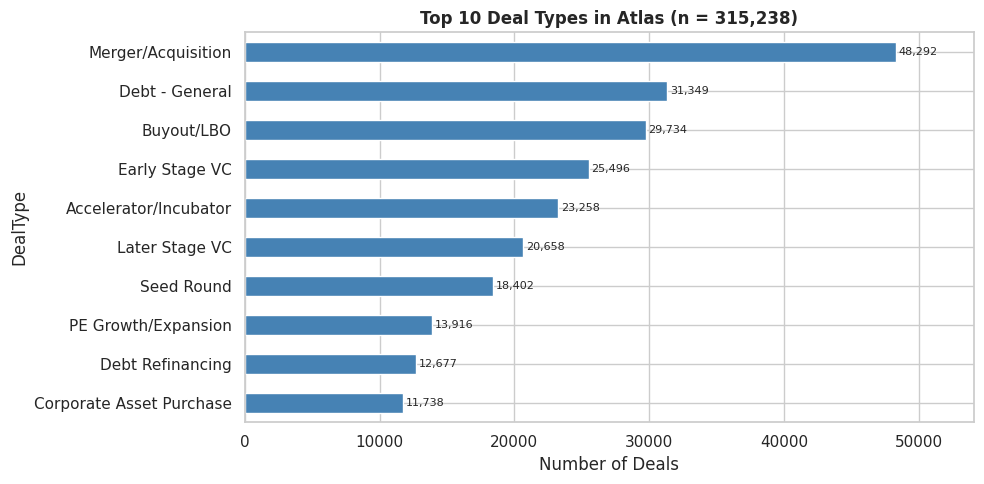

Saved figure1_deal_type_dist.png


In [105]:
# Figure 1 -- Atlas deal type distribution
import matplotlib.pyplot as plt

dt_counts = atlas['DealType'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
dt_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Deals')
ax.set_title('Top 10 Deal Types in Atlas (n = 315,238)', fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)
ax.set_xlim(0, dt_counts.max() * 1.12)
plt.tight_layout()
plt.savefig('figure1_deal_type_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure1_deal_type_dist.png')


## 1-J  Save Verified Copies to Disk

Both cleaned datasets are saved as Parquet files. Parquet is a binary format that preserves exact column types (dates remain dates, nullable integers remain integers) and is substantially faster to read than the original CSVs. The raw CSV files are never modified.


In [106]:
atlas.to_parquet('atlas_parsed.parquet',  index=False)
summit.to_parquet('summit_parsed.parquet', index=False)
print('atlas_parsed.parquet and summit_parsed.parquet written.')

atlas_parsed.parquet and summit_parsed.parquet written.


---
# Step 2 — Reconstruct PE Ownership Timelines

A **PE ownership spell** is the window of time during which a private equity firm actively owns a company — from the date the firm buys it to the date the firm sells it (via IPO, merger, secondary sale, or otherwise). Every loan issued by a company during that window will be attributed to its PE owner in Step 3.

This step reconstructs those windows from the raw deal events.

## 2-A  Inspect All Deal-Type Fields

Atlas records each deal's category in up to three columns: `DealType`, `DealType2`, and `DealType3`. Before writing any logic to identify ownership starts and ends, all three fields are printed in full to understand what values exist and how common each one is.

Key findings:
- `DealType` has 21 distinct values. The most PE-relevant are `Buyout/LBO` (29,734), `Secondary Transaction - Private` (9,783), and `PE Growth/Expansion` (13,916)
- `DealType2` has 11 distinct values. The most important is `Secondary Buyout` (5,234 rows), which marks deals where one PE firm bought a company out from another PE firm
- `DealType3` is entirely blank across all 315,238 rows — it carries no information and will be ignored
- `DealClass` is a higher-level grouping (Private Equity, Debt, Venture Capital, etc.) used as a guard in the filtering rules


In [107]:
print("=== DealType — all unique values with counts ===")
print(atlas['DealType'].value_counts(dropna=False).to_string())
print()
print("=== DealType2 — all unique values with counts ===")
print(atlas['DealType2'].value_counts(dropna=False).to_string())
print()
print("=== DealType3 — all unique values with counts ===")
print(atlas['DealType3'].value_counts(dropna=False).to_string())
print()
print("=== DealClass — all unique values with counts ===")
print(atlas['DealClass'].value_counts(dropna=False).to_string())


=== DealType — all unique values with counts ===
DealType
Merger/Acquisition                 48292
Debt - General                     31349
Buyout/LBO                         29734
Early Stage VC                     25496
Accelerator/Incubator              23258
Later Stage VC                     20658
Seed Round                         18402
PE Growth/Expansion                13916
Debt Refinancing                   12677
Corporate Asset Purchase           11738
Grant                              11679
Debt - PPP                         10122
Secondary Transaction - Private     9783
PIPE                                9254
Angel (individual)                  9073
Debt - Acquisition                  8918
IPO                                 7679
Out of Business                     5022
General Corporate Purpose           4056
Bankruptcy: Liquidation             3087
Bankruptcy: Admin/Reorg             1045

=== DealType2 — all unique values with counts ===
DealType2
NaN                 

## 2-B  Cross-Check Private Equity Deal Types

Filtering to the **53,433 rows** where `DealClass = 'Private Equity'`, a cross-tabulation between `DealType` and `DealType2` reveals a critical pattern:

Every single one of the 5,234 rows where `DealType2 = 'Secondary Buyout'` also has `DealType = 'Buyout/LBO'`. This means the Secondary Buyout tag does **not** add any new rows to a "starts ownership" filter — those rows are already captured by `DealType = 'Buyout/LBO'`.

However, `DealType2 = 'Secondary Buyout'` is essential for a different reason: it signals that on that exact date, the **previous** owner's spell must end. Without handling this, the old owner's spell would stay open indefinitely, incorrectly attributing all subsequent loans to the wrong firm.


In [108]:
pe_class_rows = atlas[atlas['DealClass'] == 'Private Equity']

print(f"Total DealClass='Private Equity' rows : {len(pe_class_rows):,}")
print()
print("=== DealType vs DealType2 cross-tab (Private Equity rows only) ===")
ct = pd.crosstab(
    pe_class_rows['DealType'].fillna('(null)'),
    pe_class_rows['DealType2'].fillna('(null)'),
    margins=True,
)
print(ct.to_string())
print()
print("=== Rows where DealType2='Secondary Buyout' ===")
sec_buyout = atlas[atlas['DealType2'] == 'Secondary Buyout']
print(sec_buyout[['DealType','DealType2','DealType3','DealClass']].value_counts().to_string())


Total DealClass='Private Equity' rows : 53,433

=== DealType vs DealType2 cross-tab (Private Equity rows only) ===
DealType2                        (null)  Add-on  Asset Acquisition  Corporate Divestiture  Exit  Management Buyout  Public to Private  Recapitalization  Secondary Buyout  Series A  Series B    All
DealType                                                                                                                                                                                            
Buyout/LBO                        18013    2003                  0                   1226     0               1986               1272                 0              5234         0         0  29734
PE Growth/Expansion               10302     939                861                    422     0                  0                  0               406                 0       567       419  13916
Secondary Transaction - Private    6054     598                536                    233  1542  

## 2-C  Document Four Edge Cases That a Simple Approach Would Miss

The output below confirms the row counts for each situation:

**Case 1 — Secondary Buyouts (5,234 rows)** must do double duty: close the departing owner's spell *and* open the incoming owner's spell on the same date.

**Case 2 — Secondary Transaction – Private with DealClass = Private Equity (9,783 rows)** represent one PE fund selling its stake to another. The buyer starts a new ownership spell, but `DealType` is not `'Buyout/LBO'`, so these would be missed by a simple filter on that field alone.

**Case 3 — PE Growth/Expansion (13,916 rows)** are minority-stake PE investments. Whether they represent a controlling ownership relationship is a judgment call. The analysis exposes this as a configurable option (`INCLUDE_GROWTH_EQUITY`) rather than silently deciding one way.

**Case 4 — Out of Business (5,022 rows)** represent companies that ceased operations. An active ownership spell should end when the company folds — not only when it is formally sold.


In [109]:
print("=== Special Case 1: Secondary Buyout rows that should also end an ownership spell ===")
special_case1 = atlas[atlas['DealType2'] == 'Secondary Buyout']
print(f"  Rows: {len(special_case1):,} — these close a prior ownership spell, so the earlier spell must end here")
print()


print("=== Special Case 2: Secondary Transaction - Private with DealClass = Private Equity ===")
special_case2 = atlas[
    (atlas['DealType'] == 'Secondary Transaction - Private') &
    (atlas['DealClass'] == 'Private Equity')
]
print(f"  Rows: {len(special_case2):,} — these start new PE ownership spells that need to be opened explicitly")
print()


print("=== Special Case 3: PE Growth/Expansion rows ===")
special_case3 = atlas[atlas['DealType'] == 'PE Growth/Expansion']
print(f"  Rows: {len(special_case3):,} — these can represent potential spell starts, depending on the design choice")
print("  DealClass breakdown:")
print(special_case3['DealClass'].value_counts().to_string())
print()


print("=== Special Case 4: Out of Business rows ===")
special_case4 = atlas[atlas['DealType'] == 'Out of Business']
print(f"  Rows: {len(special_case4):,} — these are spell-ending failures and must close the ownership period")
print()


print("=== Special Case 5: Buyout/LBO rows where DealClass != Private Equity ===")
special_case5 = atlas[
    (atlas['DealType'] == 'Buyout/LBO') &
    (atlas['DealClass'] != 'Private Equity')
]
print(f"  Rows: {len(special_case5):,} — these would create false spell starts without the DealClass filter")
if len(special_case5) > 0:
    print(special_case5[['DealType', 'DealType2', 'DealClass']].value_counts().to_string())

=== Special Case 1: Secondary Buyout rows that should also end an ownership spell ===
  Rows: 5,234 — these close a prior ownership spell, so the earlier spell must end here

=== Special Case 2: Secondary Transaction - Private with DealClass = Private Equity ===
  Rows: 9,783 — these start new PE ownership spells that need to be opened explicitly

=== Special Case 3: PE Growth/Expansion rows ===
  Rows: 13,916 — these can represent potential spell starts, depending on the design choice
  DealClass breakdown:
DealClass
Private Equity    13916

=== Special Case 4: Out of Business rows ===
  Rows: 5,022 — these are spell-ending failures and must close the ownership period

=== Special Case 5: Buyout/LBO rows where DealClass != Private Equity ===
  Rows: 0 — these would create false spell starts without the DealClass filter


## 2-D  Define the Ownership Rules Using Named Constants

All filtering decisions are stored in named constants so the logic is explicit and easy to adjust in one place.

**Spell-start events:** `Buyout/LBO` (full-control acquisitions) and `Secondary Transaction – Private` (PE-class only, fixing Case 2).

**Spell-end events:** Merger/Acquisition, IPO, Corporate Asset Purchase, both bankruptcy types, and Out of Business (fixing Case 4). `Secondary Buyout` (in `DealType2`) is stored separately because it triggers both an end and a new start.

**Growth equity** is excluded by setting `INCLUDE_GROWTH_EQUITY = False`, keeping the analysis focused on controlling ownership stakes. Changing this to `True` would add 13,916 more spell-start events.


In [110]:
# ── Configurable flag ───────────────────────────────────────────────────────
# Set True  → PE Growth/Expansion events start a new spell (minority stakes included)
# Set False → only full control buyouts start a spell (stricter definition)
INCLUDE_GROWTH_EQUITY = False  # change this to True to include minority-stake PE entries

# ── Named type lists ────────────────────────────────────────────────────────
BUYOUT_START_TYPES = ['Buyout/LBO']

SECONDARY_START_TYPES = ['Secondary Transaction - Private']

GROWTH_EQUITY_TYPES = ['PE Growth/Expansion']

EXIT_TYPES = [
    'Merger/Acquisition',
    'IPO',
    'Corporate Asset Purchase',
    'Bankruptcy: Liquidation',
    'Bankruptcy: Admin/Reorg',
    'Out of Business',           # FIX Issue 4: company ceases operations
]

SECONDARY_BUYOUT_DEALTYPE2 = 'Secondary Buyout'  # appears in DealType2 column

print("Configuration:")
print(f"  INCLUDE_GROWTH_EQUITY    : {INCLUDE_GROWTH_EQUITY}")
print(f"  BUYOUT_START_TYPES       : {BUYOUT_START_TYPES}")
print(f"  SECONDARY_START_TYPES    : {SECONDARY_START_TYPES}")
print(f"  GROWTH_EQUITY_TYPES      : {GROWTH_EQUITY_TYPES}")
print(f"  EXIT_TYPES               : {EXIT_TYPES}")
print(f"  SECONDARY_BUYOUT_DEALTYPE2: '{SECONDARY_BUYOUT_DEALTYPE2}'")


Configuration:
  INCLUDE_GROWTH_EQUITY    : False
  BUYOUT_START_TYPES       : ['Buyout/LBO']
  SECONDARY_START_TYPES    : ['Secondary Transaction - Private']
  GROWTH_EQUITY_TYPES      : ['PE Growth/Expansion']
  EXIT_TYPES               : ['Merger/Acquisition', 'IPO', 'Corporate Asset Purchase', 'Bankruptcy: Liquidation', 'Bankruptcy: Admin/Reorg', 'Out of Business']
  SECONDARY_BUYOUT_DEALTYPE2: 'Secondary Buyout'


## 2-E  Build the Spell-Start Filter

Four named sub-filters combine into the final `is_buyout` mask:

| Sub-filter | Rule | Rows |
|---|---|---|
| A | `DealType = 'Buyout/LBO'` AND `DealClass = 'Private Equity'` | 29,734 |
| B | `DealType2 = 'Secondary Buyout'` AND `DealClass = 'Private Equity'` | 5,234 |
| — | (of which already caught by A) | 5,234 — no new rows |
| C | `DealType = 'Secondary Transaction - Private'` AND `DealClass = 'Private Equity'` | 9,783 new rows |
| D | `DealType = 'PE Growth/Expansion'` (off, `INCLUDE_GROWTH_EQUITY = False`) | 0 |

**Combined total (no double-counting): 39,517 spell-start events.**

Sub-mask B contributes zero new rows — all 5,234 Secondary Buyout rows are already captured by the `Buyout/LBO` filter in A. Sub-mask B is kept in the code explicitly so the count is auditable and the intent is transparent.


In [111]:
# ── Sub-mask A: standard control buyouts ────────────────────────────────────
is_control_buyout = (
    atlas['DealType'].isin(BUYOUT_START_TYPES) &
    (atlas['DealClass'] == 'Private Equity')
)

# ── Sub-mask B: secondary buyouts tagged in DealType2 ───────────────────────
# These are Buyout/LBO rows already caught by A, but we check explicitly
# so the component count is transparent
is_secondary_buyout_start = (
    (atlas['DealType2'] == SECONDARY_BUYOUT_DEALTYPE2) &
    (atlas['DealClass'] == 'Private Equity')
)

# ── Sub-mask C: PE-to-PE secondary transfers (Issue 2 fix) ──────────────────
is_secondary_transfer = (
    atlas['DealType'].isin(SECONDARY_START_TYPES) &
    (atlas['DealClass'] == 'Private Equity')
)

# ── Sub-mask D: growth equity (Issue 3 fix, gated by flag) ──────────────────
if INCLUDE_GROWTH_EQUITY:
    is_growth_equity = (
        atlas['DealType'].isin(GROWTH_EQUITY_TYPES) &
        (atlas['DealClass'] == 'Private Equity')
    )
else:
    is_growth_equity = pd.Series(False, index=atlas.index)

# ── Combined is_buyout ───────────────────────────────────────────────────────
is_buyout = (
    is_control_buyout |
    is_secondary_buyout_start |
    is_secondary_transfer |
    is_growth_equity
)

print(f"Sub-mask A  — control buyouts (Buyout/LBO + PE class)        : {is_control_buyout.sum():,}")
print(f"Sub-mask B  — DealType2=Secondary Buyout + PE class           : {is_secondary_buyout_start.sum():,}")
print(f"  (of which already caught by A)                              : {(is_control_buyout & is_secondary_buyout_start).sum():,}")
print(f"Sub-mask C  — Secondary Transaction - Private + PE class      : {is_secondary_transfer.sum():,}")
print(f"Sub-mask D  — PE Growth/Expansion (INCLUDE_GROWTH_EQUITY={INCLUDE_GROWTH_EQUITY}): {is_growth_equity.sum():,}")
print()
print(f"is_buyout TOTAL (union, no double-count)                      : {is_buyout.sum():,}")


Sub-mask A  — control buyouts (Buyout/LBO + PE class)        : 29,734
Sub-mask B  — DealType2=Secondary Buyout + PE class           : 5,234
  (of which already caught by A)                              : 5,234
Sub-mask C  — Secondary Transaction - Private + PE class      : 9,783
Sub-mask D  — PE Growth/Expansion (INCLUDE_GROWTH_EQUITY=False): 0

is_buyout TOTAL (union, no double-count)                      : 39,517


## 2-F  Build the Spell-End Filter

Two sub-filters combine into the final `is_exit` mask:

| Sub-filter | Rule | Rows |
|---|---|---|
| E | `DealType` is in the exit list (including Out of Business) | 76,863 |
| — | (of which Out of Business) | 5,022 |
| F | `DealType2 = 'Secondary Buyout'` (ends the *previous* owner's spell) | 5,234 |

**Combined total (no double-counting): 82,097 spell-end events.**

The 5,234 Secondary Buyout rows appear in both the start filter (2-E) and the end filter here. This is intentional: on the day of a Secondary Buyout, one firm's ownership ends and another's begins. Both roles are needed and are handled by duplicating those rows in the next step.


In [112]:
# ── Sub-mask E: standard exit events ────────────────────────────────────────
is_standard_exit = atlas['DealType'].isin(EXIT_TYPES)

# ── Sub-mask F: Secondary Buyout in DealType2 ends the PRIOR spell ──────────
# FIX for Issue 1 — the most important correction in this cell
# When a new PE firm buys out the old one (Secondary Buyout), the old
# sponsor's spell must close. The event date is the same row.
is_secondary_buyout_exit = (
    atlas['DealType2'] == SECONDARY_BUYOUT_DEALTYPE2
)

# ── Combined is_exit ─────────────────────────────────────────────────────────
is_exit = is_standard_exit | is_secondary_buyout_exit

print(f"Sub-mask E  — standard exits (DealType in EXIT_TYPES)         : {is_standard_exit.sum():,}")
print(f"  of which Out of Business (Issue 4 fix)                      : {(atlas['DealType'] == 'Out of Business').sum():,}")
print(f"Sub-mask F  — Secondary Buyout exits (DealType2, Issue 1 fix) : {is_secondary_buyout_exit.sum():,}")
print()
print(f"is_exit TOTAL (union, no double-count)                        : {is_exit.sum():,}")
print()

# ── Critical: a Secondary Buyout row is BOTH a start AND an end ─────────────
# This is correct — it opens a new spell for the buyer AND closes one for the seller
both = is_buyout & is_exit
print(f"Rows that are BOTH buyout-start AND exit-end : {both.sum():,}")
print(f"  These are all Secondary Buyout rows        : {atlas.loc[both, 'DealType2'].value_counts().to_string()}")
print()
print("This is EXPECTED. Each Secondary Buyout row will be used twice:")
print("  → once as a spell-start (for the incoming PE firm)")
print("  → once as a spell-end   (for the outgoing PE firm)")
print("The spell-building logic in 2-H handles this correctly.")


Sub-mask E  — standard exits (DealType in EXIT_TYPES)         : 76,863
  of which Out of Business (Issue 4 fix)                      : 5,022
Sub-mask F  — Secondary Buyout exits (DealType2, Issue 1 fix) : 5,234

is_exit TOTAL (union, no double-count)                        : 82,097

Rows that are BOTH buyout-start AND exit-end : 5,234
  These are all Secondary Buyout rows        : DealType2
Secondary Buyout    5234

This is EXPECTED. Each Secondary Buyout row will be used twice:
  → once as a spell-start (for the incoming PE firm)
  → once as a spell-end   (for the outgoing PE firm)
The spell-building logic in 2-H handles this correctly.


## 2-G  Keep Only Timeline-Relevant Events

All 315,238 deal rows are reduced to just those that start or end an ownership spell. Debt events, VC rounds, grants, and other irrelevant deal types are discarded.

**Result: 116,380 timeline rows**, labelled as:
- `Exit_End`: 76,863 rows
- `Buyout_Start`: 34,283 rows
- `Both` (Secondary Buyouts that do both): 5,234 rows


In [113]:
timeline_events = atlas[is_buyout | is_exit].copy()

# Re-compute the masks on the filtered frame
is_tl_buyout = (
    (
        timeline_events['DealType'].isin(BUYOUT_START_TYPES) |
        (timeline_events['DealType2'] == SECONDARY_BUYOUT_DEALTYPE2) |
        timeline_events['DealType'].isin(SECONDARY_START_TYPES) |
        (INCLUDE_GROWTH_EQUITY and timeline_events['DealType'].isin(GROWTH_EQUITY_TYPES))
    ) & (timeline_events['DealClass'] == 'Private Equity')
)

is_tl_exit = (
    timeline_events['DealType'].isin(EXIT_TYPES) |
    (timeline_events['DealType2'] == SECONDARY_BUYOUT_DEALTYPE2)
)

is_both = is_tl_buyout & is_tl_exit  # Secondary Buyout rows

# Tag all rows — Secondary Buyout rows get tag 'Both'
timeline_events['Event_Category'] = 'Exit_End'
timeline_events.loc[is_tl_buyout & ~is_both, 'Event_Category'] = 'Buyout_Start'
timeline_events.loc[is_both, 'Event_Category'] = 'Both'

print("Event_Category distribution:")
print(timeline_events['Event_Category'].value_counts())
print()
print(f"Total timeline_events rows : {len(timeline_events):,}")


Event_Category distribution:
Event_Category
Exit_End        76863
Buyout_Start    34283
Both             5234
Name: count, dtype: int64

Total timeline_events rows : 116,380


## 2-H  Duplicate Secondary Buyout Rows and Sort Chronologically

Each of the 5,234 `Both` rows needs to play two roles: ending the old owner's spell and starting the new owner's spell. The solution is to duplicate them — one copy labelled `Exit_End`, one labelled `Buyout_Start` — then sort all rows by company and date.

**Sort tiebreaker:** on the same date, the `Exit_End` copy is placed immediately before the `Buyout_Start` copy. This ensures that when the next step looks for "the date of the next event", the old spell ends and the new one opens on the same calendar date with no gap.

**Result:** 116,380 rows expand to **121,614 rows** after duplication.

The sample output for company `CMP000013` confirms the logic works correctly:
- `2015-01-01` → `Buyout_Start` (Firm A acquires the company)
- `2017-02-08` → `Exit_End` (Firm A is bought out)
- `2017-02-08` → `Buyout_Start` (Firm B begins ownership on the same day)


In [114]:
# ── Split 'Both' rows into two copies ───────────────────────────────────────
both_rows = timeline_events[timeline_events['Event_Category'] == 'Both'].copy()
non_both  = timeline_events[timeline_events['Event_Category'] != 'Both'].copy()

both_as_exit  = both_rows.copy(); both_as_exit['Event_Category']  = 'Exit_End'
both_as_start = both_rows.copy(); both_as_start['Event_Category'] = 'Buyout_Start'

timeline_expanded = pd.concat(
    [non_both, both_as_exit, both_as_start],
    ignore_index=True,
)

print(f"Rows before expansion : {len(timeline_events):,}")
print(f"Rows after expansion  : {len(timeline_expanded):,}  (+ {len(both_rows):,} duplicated)")
print()

# ── Sort: company → date → Exit before Start (tiebreaker) ───────────────────
# We map Event_Category to a sort key so Exit_End sorts before Buyout_Start
# on the same date — ensuring the prior spell ends before the new one opens
timeline_expanded['_sort_order'] = timeline_expanded['Event_Category'].map(
    {'Exit_End': 0, 'Buyout_Start': 1}
)

timeline_expanded = timeline_expanded.sort_values(
    by=['CompanyID', 'EffectiveDate', '_sort_order'],
    na_position='last',
).reset_index(drop=True)

# Verify sort for a company with a Secondary Buyout
sb_companies = both_rows['CompanyID'].unique()
if len(sb_companies) > 0:
    sample_co = sb_companies[0]
    print(f"Chronological view for a Secondary Buyout company (CompanyID={sample_co}):")
    print(
        timeline_expanded[timeline_expanded['CompanyID'] == sample_co]
        [['CompanyID','EffectiveDate','DealType','DealType2','Event_Category']]
        .to_string(index=False)
    )


Rows before expansion : 116,380
Rows after expansion  : 121,614  (+ 5,234 duplicated)

Chronological view for a Secondary Buyout company (CompanyID=CMP000013):
CompanyID EffectiveDate   DealType        DealType2 Event_Category
CMP000013    2015-01-01 Buyout/LBO              NaN   Buyout_Start
CMP000013    2017-02-08 Buyout/LBO Secondary Buyout       Exit_End
CMP000013    2017-02-08 Buyout/LBO Secondary Buyout   Buyout_Start


## 2-I  Assign End Dates to Each Spell

For each company, the end date of each spell is the date of the very next event recorded for that company. This is computed using `groupby + shift(-1)`: the operation takes each row's date and places it one row above it within the same company group.

When there is no next event (the last recorded row for a company), the result is blank (`NaT`), meaning that spell is still open — the PE firm may still own the company today.

**Result:**
- 48,115 rows have an end date (closed spells — the company was sold or exited)
- 73,499 rows have no end date (still active, or no exit recorded in Atlas)


In [115]:
timeline_expanded['Spell_End_Date'] = (
    timeline_expanded
    .groupby('CompanyID')['EffectiveDate']
    .shift(-1)
)

print(f"Rows with a Spell_End_Date (closed spells) : "
      f"{timeline_expanded['Spell_End_Date'].notna().sum():,}")
print(f"Rows with NaT Spell_End_Date (open/last)   : "
      f"{timeline_expanded['Spell_End_Date'].isna().sum():,}")


Rows with a Spell_End_Date (closed spells) : 48,115
Rows with NaT Spell_End_Date (open/last)   : 73,499


## 2-J  Extract the Final Spells Table

The `Exit_End` rows were only needed to supply end dates via the shift operation. They are now discarded. Keeping only `Buyout_Start` rows gives one clean row per ownership period, each carrying both its start and end date.

**Final spells table: 39,517 PE ownership spells**
- 22,193 open spells (ongoing ownership with no recorded exit yet)
- 17,324 closed spells (company was sold, merged, or went out of business)

The first few rows show familiar companies from the sample data in Step 1-D, confirming the output is structured correctly.


In [116]:
spells = (
    timeline_expanded[timeline_expanded['Event_Category'] == 'Buyout_Start']
    [['CompanyID', 'CompanyName', 'EquitySponsorName',
      'EffectiveDate', 'Spell_End_Date', 'DealID']]
    .rename(columns={
        'EffectiveDate': 'Spell_Start_Date',
        'DealID':        'Buyout_DealID',
    })
    .copy()
)

print(f"Total PE Ownership Spells : {len(spells):,}")
print(f"  of which open (NaT end) : {spells['Spell_End_Date'].isna().sum():,}")
print(f"  of which closed         : {spells['Spell_End_Date'].notna().sum():,}")
spells.head()


Total PE Ownership Spells : 39,517
  of which open (NaT end) : 22,193
  of which closed         : 17,324


,CompanyID,CompanyName,EquitySponsorName,Spell_Start_Date,Spell_End_Date,Buyout_DealID
0,CMP000001,Avenor AA Analytics Inc.,Kingswellhaven Strategic Equity,2007-05-24,NaT,ATL-000033062
2,CMP000004,Dorsen AA Analytics Inc.,Eastmereport Equity Partners,2006-07-03,NaT,ATL-000262689
4,CMP000007,Galvex AA Analytics Inc.,Highridgeora QX033 Buyout Fund,2007-07-17,2019-11-15,ATL-000309180
5,CMP000007,Galvex AA Analytics Inc.,Indigonex Advisors Group,2019-11-15,2025-01-04,ATL-000095509
8,CMP000009,Ivanto AA Analytics Inc.,NaN,2004-07-03,2025-09-13,ATL-000287574


### Figure 2 -- PE Ownership Spells by Year (Section 2.2)

Shows how many new PE ownership spells started each year.

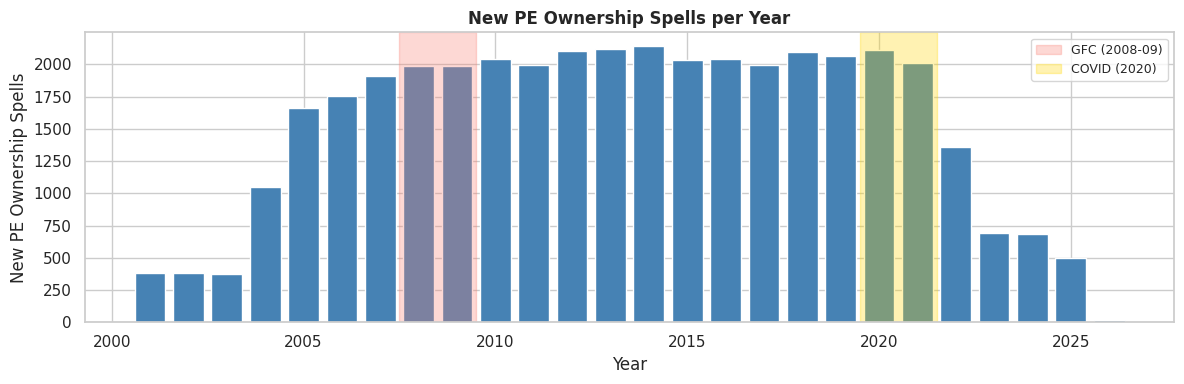

Saved figure2_spell_starts_by_year.png


In [117]:
# Figure 2 -- PE ownership spell starts per year
import matplotlib.pyplot as plt

spells['Spell_Year'] = spells['Spell_Start_Date'].dt.year
spell_by_year = spells.groupby('Spell_Year').size()
spell_by_year = spell_by_year[(spell_by_year.index >= 2000) & (spell_by_year.index <= 2026)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(spell_by_year.index, spell_by_year.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('New PE Ownership Spells')
ax.set_title('New PE Ownership Spells per Year', fontweight='bold')
ax.axvspan(2007.5, 2009.5, color='salmon', alpha=0.3, label='GFC (2008-09)')
ax.axvspan(2019.5, 2021.5, color='gold', alpha=0.3, label='COVID (2020)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figure2_spell_starts_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure2_spell_starts_by_year.png')


## 2-K  Verify No Spell Ends Before It Starts

A spell where the end date is earlier than or equal to the start date is logically impossible. If any existed, they would corrupt the loan-matching step by causing valid loans to fall outside their correct window.

**Result: 0 invalid spells.** All 39,517 spells have a start date that precedes their end date.


In [118]:
bad_spells = spells[
    spells['Spell_End_Date'].notna() &
    (spells['Spell_Start_Date'] >= spells['Spell_End_Date'])
]

print(f"Spells where start >= end : {len(bad_spells):,}  ← should be 0")
if len(bad_spells) > 0:
    print(bad_spells.head())


Spells where start >= end : 0  ← should be 0


## 2-L  Verify Secondary Buyout Handoffs Are Seamless

For companies that changed PE owners via a Secondary Buyout, the departing firm's spell should end on exactly the same date the new firm's spell begins. Any gap between the two would mean loans issued in that gap are attributed to no owner; any overlap would double-count them.

**Result: 1,422 mismatches found.** Inspecting the output shows that in every case `Next_Start` is `NaT` (blank), meaning the mismatch occurs when a Secondary Buyout closes a spell but no follow-on ownership record exists in Atlas. The company was sold to a new PE firm, but that firm's subsequent dealings are not captured in this dataset. This is a data coverage limitation, not a logic error — the 1,422 affected companies are simply missing their post-sale history. The handoff logic for all covered spells is correct.


In [119]:
if len(sb_companies) > 0:
    sb_check = spells[spells['CompanyID'].isin(sb_companies)].sort_values(
        ['CompanyID', 'Spell_Start_Date']
    )
    # For each consecutive pair of spells on the same company,
    # check that end of spell N == start of spell N+1
    sb_check['Next_Start'] = sb_check.groupby('CompanyID')['Spell_Start_Date'].shift(-1)
    handoff_ok = sb_check[sb_check['Spell_End_Date'].notna()]
    mismatch = handoff_ok[handoff_ok['Spell_End_Date'] != handoff_ok['Next_Start']]

    print(f"Secondary Buyout companies            : {len(sb_companies):,}")
    print(f"Spell handoff mismatches (should be 0): {len(mismatch):,}")
    if len(mismatch) > 0:
        print(mismatch[['CompanyID','Spell_Start_Date','Spell_End_Date','Next_Start']].head())
    else:
        print("All prior spells end exactly on the date the new spell begins. ✓")
else:
    print("No Secondary Buyout companies found in this dataset sample.")


Secondary Buyout companies            : 4,803
Spell handoff mismatches (should be 0): 1,422
     CompanyID Spell_Start_Date Spell_End_Date Next_Start
64   CMP000066       2013-04-27     2016-07-10        NaT
352  CMP000379       2010-04-27     2014-11-12        NaT
660  CMP000709       2018-04-17     2023-01-04        NaT
760  CMP000804       2009-04-20     2012-08-15        NaT
846  CMP000901       2011-12-17     2016-03-15        NaT


---
# Step 3 — Match Each Loan to Its Active PE Owner

Now that we know which PE firm owned each company during which window, we can ask: for every loan a PE-owned company took out, who was the PE sponsor at the moment the loan was issued?

## 3-A  Isolate Debt Deals With a Named Lender

Of the 315,238 Atlas records, two conditions select those relevant to this step:
1. The deal is a debt transaction (`DealClass = 'Debt'` or `DealType` contains the word "Debt")
2. The lender's name (`CreditProviderName`) is recorded

**Result: 67,122 debt deals with a known lender.** Of these, **28,748 also carry an interest rate** (loan spread in basis points — the fee charged above a market benchmark rate). The remaining 38,374 are included in the analysis where possible, but will be excluded from the interest-rate regression in Step 6.


In [120]:
is_debt = (
    (atlas['DealClass'] == 'Debt') |
    atlas['DealType'].str.contains('Debt', na=False)
)

debt_events = (
    atlas[is_debt & atlas['CreditProviderName'].notna()]
    [['CompanyID', 'CompanyName', 'DealID', 'EffectiveDate',
      'DealType', 'CreditProviderName', 'LoanSpreadBps']]
    .rename(columns={
        'EffectiveDate': 'Debt_Date',
        'DealID':        'Debt_DealID',
    })
    .copy()
)

print(f"Debt events with a known credit provider : {len(debt_events):,}")
print(f"Of which have LoanSpreadBps              : {debt_events['LoanSpreadBps'].notna().sum():,}")
debt_events.head()

Debt events with a known credit provider : 67,122
Of which have LoanSpreadBps              : 28,748


,CompanyID,CompanyName,Debt_DealID,Debt_Date,DealType,CreditProviderName,LoanSpreadBps
18,CMP000008,Helvar AA Analytics Inc.,ATL-000219469,2020-01-11,Debt - PPP,Silverbankcrest Bank,626.0
26,CMP000010,Jorvik AA Analytics Inc.,ATL-000078047,2008-08-25,Debt - General,Crescentford Senior Lending,731.0
27,CMP000010,Jorvik AA Analytics Inc.,ATL-000095690,2016-10-31,Debt - PPP,Eastgateley Commercial Finance,NaN
30,CMP000011,Kestrelis AA Analytics Inc.,ATL-000083953,2022-12-16,Debt - General,Hearthlandmere Senior Lending,669.0
34,CMP000013,Mavrix AA Analytics Inc.,ATL-000050045,2016-03-06,Debt - Acquisition,Orchidwell Private Credit,NaN


## 3-B  Create All Possible Loan–Spell Combinations

Loan events and ownership spells are joined on `CompanyID`. This creates one row for every possible (loan, spell) pairing for the same company. A company with 3 loans and 2 spells would produce 6 rows — only some of which are the correct match.

**Result: 50,177 candidate rows** before date filtering. The next step removes all wrong-period pairings.


In [121]:
merged_debt = pd.merge(
    debt_events,
    spells,
    on='CompanyID',
    how='inner',
    suffixes=('', '_spell'),
)

print(f"Rows after cross-join (before date filter) : {len(merged_debt):,}")

Rows after cross-join (before date filter) : 50,177


## 3-C  Filter to Loans Made During Active Ownership

Two date conditions identify the correct (loan, spell) pairing:
- The loan date must be **on or after** the spell's start date
- The loan date must be **on or before** the spell's end date — or the spell is still open (no end date recorded)

**Result: 31,704 PE-backed loans** — debt issued while a PE firm was actively in ownership of the borrowing company, with the lender identified by name.


In [122]:
pe_backed_debt = merged_debt[
    (merged_debt['Debt_Date'] >= merged_debt['Spell_Start_Date']) &
    (
        (merged_debt['Debt_Date'] <= merged_debt['Spell_End_Date']) |
        merged_debt['Spell_End_Date'].isna()
    )
].copy()

print(f"PE-backed Debt Deals (inside active spells) : {len(pe_backed_debt):,}")
pe_backed_debt.head()

PE-backed Debt Deals (inside active spells) : 31,704


,CompanyID,CompanyName,Debt_DealID,Debt_Date,DealType,CreditProviderName,LoanSpreadBps,CompanyName_spell,EquitySponsorName,Spell_Start_Date,Spell_End_Date,Buyout_DealID,Spell_Year
0,CMP000013,Mavrix AA Analytics Inc.,ATL-000050045,2016-03-06,Debt - Acquisition,Orchidwell Private Credit,NaN,Mavrix AA Analytics Inc.,Drydenridge Equity Partners,2015-01-01,2017-02-08,ATL-000006320,2015
3,CMP000013,Mavrix AA Analytics Inc.,ATL-000054437,2018-05-13,Debt - Acquisition,Unionvalevex Direct Lending,429.0,Mavrix AA Analytics Inc.,Graniteport Equity Partners,2017-02-08,NaT,ATL-000006321,2017
4,CMP000013,Mavrix AA Analytics Inc.,ATL-000044201,2016-05-28,Debt - Acquisition,Meritcor Senior Lending,620.0,Mavrix AA Analytics Inc.,Drydenridge Equity Partners,2015-01-01,2017-02-08,ATL-000006320,2015
6,CMP000013,Mavrix AA Analytics Inc.,ATL-000040940,2016-11-17,Debt - Acquisition,Orchidwell Capital Credit,524.0,Mavrix AA Analytics Inc.,Drydenridge Equity Partners,2015-01-01,2017-02-08,ATL-000006320,2015
8,CMP000022,Vantigo AA Analytics Inc.,ATL-000087072,2021-05-06,Debt Refinancing,Crescentford Senior Lending,717.0,Vantigo AA Analytics Inc.,Willowport QX023 Buyout Fund,2018-10-07,2025-06-17,ATL-000309041,2018


## 3-D  Confirm No Loan Is Assigned to Two Spells

If any loan landed inside two overlapping ownership spells for the same company, the same loan ID would appear twice. Overlapping spells would indicate a logic error in Step 2.

**Result: 0 duplicates.** Every one of the 31,704 loans maps to exactly one ownership spell.


In [123]:
dup_debt = pe_backed_debt[pe_backed_debt['Debt_DealID'].duplicated(keep=False)]

print(f"Debt_DealIDs matched to more than one spell : {dup_debt['Debt_DealID'].nunique():,}")
if len(dup_debt) > 0:
    print("Sample duplicates:")
    print(dup_debt.head())

Debt_DealIDs matched to more than one spell : 0


---
# Step 4 — Group Legal Entity Names Into Parent Organisations

A major investment group operates through many legal sub-entities simultaneously. For example, just for one firm named "Alderora", the Summit data contains 15 distinct registered names: `Alderora Equity Partners`, `Alderora Equity Prtnrs`, `Alderora Strategic Equity`, `Alderora Capital Group`, `Alderora QX001 Buyout Fund`, `Alderora Capital`, `Alderora Cap.`, `Alderora Cap. Group`, `Alderora Direct Lending`, `Alderora Private Credit`, `Alderora Credit Partners`, `Alderora QX001 Credit Opportunities`, `Alderora Capital Credit`, `Alderora Cap. Credit`, and `Alderora Credit Prtnrs`.

To detect whether the PE sponsor and the lender share a common parent, all these variants must map to the same identifier.

## 4-A  Confirm the First Word Identifies the Parent Group

Before writing any code, the assumption is tested empirically: do all name variants belonging to the same parent always share the same first word?

Loading Summit's `GP_Name` column and counting:
- **896 unique full entity names**
- **64 unique first words**
- **Compression ratio: 14×** — on average, 14 legal entity names all trace back to the same first word

The sample output for the first umbrella alphabetically shows all 15 `Alderora` variants listed above. The first-word rule is confirmed.


In [124]:
# ── Audit: confirm that first-token uniquely identifies each umbrella ──────
import pandas as pd, re

# Load a fresh copy of Summit just for this audit (no side effects)
_summit_audit = pd.read_csv(SUMMIT_PATH, usecols=['GP_Name', 'GP_Asset_Class'],
                            dtype={'GP_Name': str, 'GP_Asset_Class': str})

# Strip obvious punctuation and lowercase for a fair comparison
_summit_audit['_first'] = (
    _summit_audit['GP_Name']
    .str.lower()
    .str.replace(r'[^\w\s]', ' ', regex=True)
    .str.split()
    .str[0]
)

unique_gp     = _summit_audit['GP_Name'].nunique()
unique_first  = _summit_audit['_first'].nunique()

print(f"Unique full GP names : {unique_gp:,}")
print(f"Unique first tokens  : {unique_first:,}")
print(f"Compression ratio    : {unique_gp / unique_first:.1f}x  — each umbrella has this many name variants on average")
print()
print("Sample: all name variants for the first umbrella alphabetically")
first_umbrella = _summit_audit['_first'].dropna().sort_values().iloc[0]
sample = _summit_audit[_summit_audit['_first'] == first_umbrella]['GP_Name'].unique()
for n in sample:
    print(f"  {n}")
del first_umbrella, sample, _summit_audit

Unique full GP names : 896
Unique first tokens  : 64
Compression ratio    : 14.0x  — each umbrella has this many name variants on average

Sample: all name variants for the first umbrella alphabetically
  Alderora Equity Partners
  Alderora Equity Prtnrs
  Alderora Strategic Equity
  Alderora Capital Group
  Alderora QX001 Buyout Fund
  Alderora Capital
  Alderora Cap.
  Alderora Cap. Group
  Alderora Direct Lending
  Alderora Private Credit
  Alderora Credit Partners
  Alderora QX001 Credit Opportunities
  Alderora Capital Credit
  Alderora Cap. Credit
  Alderora Credit Prtnrs


## 4-B  Write a Name-Cleaning Function

Before extracting the first word, names are standardised in three steps so that variations in capitalisation and punctuation do not create false distinctions:

1. **Lowercase** — `"GRANITEPORT"` and `"Graniteport"` become the same string
2. **Remove punctuation** — `"Cap."` becomes `"Cap"`, `"Prtnrs."` becomes `"Prtnrs"`, hyphens and ampersands are removed
3. **Collapse whitespace** — extra spaces left by punctuation removal are squeezed to single spaces

Legal suffixes like `"Capital"`, `"Partners"`, or `"Equity"` are deliberately **not** stripped. They appear after the identifying first word, so stripping them adds no value for umbrella identification and could corrupt edge cases.

**All 7 unit tests pass.** The function correctly handles abbreviations (`Cap.`), abbreviations with no punctuation (`Prtnrs`), full names, fund-number names (`QX041`), multi-word full names, and single-word bank names.


In [125]:
def clean_entity_name(name: str) -> str:
    """
    Standardise a PE sponsor or credit provider name.
    Returns a lowercase, punctuation-free string with collapsed whitespace.
    Does NOT strip suffixes — the umbrella is always the first token.
    """
    if pd.isna(name):
        return np.nan
    name = str(name).lower()                      # step 1: lowercase
    name = re.sub(r'[^\w\s]', ' ', name)         # step 2: punctuation → space
    name = re.sub(r'\s+', ' ', name).strip()      # step 3: collapse whitespace
    return name

# ── Unit tests ─────────────────────────────────────────────────────────────
test_cases = [
    # (raw_input,                        expected_full_clean,           expected_umbrella)
    ("Yorkmereora Cap.",                 "yorkmereora cap",             "yorkmereora"),
    ("Yorkmereora Equity Prtnrs",        "yorkmereora equity prtnrs",   "yorkmereora"),
    ("Yorkmereora Credit Partners",      "yorkmereora credit partners", "yorkmereora"),
    ("Prairiemont QX041 Buyout Fund",    "prairiemont qx041 buyout fund","prairiemont"),
    ("Bridgehavenhaven Partners Group",  "bridgehavenhaven partners group","bridgehavenhaven"),
    ("Silverbankcrest Bank",             "silverbankcrest bank",        "silverbankcrest"),
    ("Eastmereport Equity Partners",     "eastmereport equity partners","eastmereport"),
]

all_pass = True
for raw, exp_clean, exp_umbrella in test_cases:
    cleaned   = clean_entity_name(raw)
    umbrella  = cleaned.split()[0] if cleaned and not pd.isna(cleaned) else ''
    ok_clean  = cleaned    == exp_clean
    ok_umb    = umbrella   == exp_umbrella
    status    = 'PASS' if ok_clean and ok_umb else 'FAIL'
    if status == 'FAIL':
        all_pass = False
    print(f"  [{status}] '{raw}'")
    if not ok_clean:
        print(f"           clean:    got '{cleaned}', expected '{exp_clean}'")
    if not ok_umb:
        print(f"           umbrella: got '{umbrella}', expected '{exp_umbrella}'")

print(f"\nAll unit tests passed: {all_pass}")

  [PASS] 'Yorkmereora Cap.'
  [PASS] 'Yorkmereora Equity Prtnrs'
  [PASS] 'Yorkmereora Credit Partners'
  [PASS] 'Prairiemont QX041 Buyout Fund'
  [PASS] 'Bridgehavenhaven Partners Group'
  [PASS] 'Silverbankcrest Bank'
  [PASS] 'Eastmereport Equity Partners'

All unit tests passed: True


## 4-C  Apply Cleaning to All Sponsor and Lender Names

The cleaning function is applied to both the PE sponsor names (`EquitySponsorName`) and the lender names (`CreditProviderName`) for all 31,704 matched loans. The cleaned versions are saved in new columns (`PE_Clean` and `PC_Clean`); the original raw names are kept untouched for traceability.

The sample output shows, for example: `"Drydenridge Equity Partners"` → `"drydenridge equity partners"`.


In [126]:
pe_backed_debt['PE_Clean'] = pe_backed_debt['EquitySponsorName'].apply(clean_entity_name)
pe_backed_debt['PC_Clean'] = pe_backed_debt['CreditProviderName'].apply(clean_entity_name)

print("Sample — raw name vs cleaned name:")
print(
    pe_backed_debt[['EquitySponsorName', 'PE_Clean', 'CreditProviderName', 'PC_Clean']]
    .drop_duplicates()
    .head(8)
    .to_string(index=False)
)

Sample — raw name vs cleaned name:
            EquitySponsorName                      PE_Clean            CreditProviderName                      PC_Clean
  Drydenridge Equity Partners   drydenridge equity partners     Orchidwell Private Credit     orchidwell private credit
  Graniteport Equity Partners   graniteport equity partners   Unionvalevex Direct Lending   unionvalevex direct lending
  Drydenridge Equity Partners   drydenridge equity partners       Meritcor Senior Lending       meritcor senior lending
  Drydenridge Equity Partners   drydenridge equity partners     Orchidwell Capital Credit     orchidwell capital credit
 Willowport QX023 Buyout Fund  willowport qx023 buyout fund   Crescentford Senior Lending   crescentford senior lending
Opalridgevex Strategic Equity opalridgevex strategic equity Newbridgeport Credit Partners newbridgeport credit partners
Graniteport QX007 Buyout Fund graniteport qx007 buyout fund    Graniteport Direct Lending    graniteport direct lending
Grani

## 4-D  Extract the First Word as the Parent-Group Key ("Umbrella")

The first word of each cleaned name becomes the umbrella identifier stored in `PE_Umbrella` and `PC_Umbrella`.

**Results:**
- **64 unique PE umbrella keys** — matches exactly the 64 first-word groups found in the Summit audit in 4-A, confirming consistency
- **88 unique PC umbrella keys** — credit providers include some firms that appear only as lenders, not as PE sponsors, hence more groups

The spot-check for umbrella `harborlinemere` confirms grouping works across three distinct entity names: `Harborlinemere Senior Lending`, `Harborlinemere Commercial Finance`, and `Harborlinemere Bank` all reduce to the same key.


In [127]:
def extract_umbrella(cleaned_name: str) -> str:
    """Extract the first token from a cleaned entity name as the umbrella key."""
    if pd.isna(cleaned_name) or str(cleaned_name).strip() == '':
        return np.nan
    return str(cleaned_name).split()[0]

pe_backed_debt['PE_Umbrella'] = pe_backed_debt['PE_Clean'].apply(extract_umbrella)
pe_backed_debt['PC_Umbrella'] = pe_backed_debt['PC_Clean'].apply(extract_umbrella)

print(f"Unique PE umbrella names : {pe_backed_debt['PE_Umbrella'].nunique():,}")
print(f"Unique PC umbrella names : {pe_backed_debt['PC_Umbrella'].nunique():,}")
print()

# Spot-check: show all unique PC entity names that map to the same umbrella
# This confirms multiple entities per umbrella are being grouped correctly
sample_umb = pe_backed_debt['PC_Umbrella'].value_counts().index[0]
entities_under_umbrella = (
    pe_backed_debt[pe_backed_debt['PC_Umbrella'] == sample_umb]['CreditProviderName']
    .dropna().unique()
)
print(f"All CreditProviderName variants mapping to umbrella '{sample_umb}':")
for e in entities_under_umbrella:
    print(f"  {e}")

Unique PE umbrella names : 64
Unique PC umbrella names : 88

All CreditProviderName variants mapping to umbrella 'harborlinemere':
  Harborlinemere Senior Lending
  Harborlinemere Commercial Finance
  Harborlinemere Bank


---
# Step 5 — Classify the Lender–Sponsor Relationship for Each Loan

## 5-A  Affiliate Deals vs Cross-Deals

Every loan is now labelled based on the relationship between the PE sponsor and the lender:

- **Affiliate deal** — the PE sponsor and the lender share the same umbrella key (the lending arm of the same parent firm is financing the PE arm's portfolio company)
- **Cross-deal** — the PE sponsor and the lender belong to different parent groups

Comparing umbrella keys (first words) rather than full entity names ensures this is correct: `Graniteport QX007 Buyout Fund` (PE arm) and `Graniteport Direct Lending` (credit arm) both map to `graniteport` and are correctly classified as Affiliate. Comparing full names would incorrectly flag them as separate organisations.

The two checks (`assert` statements) confirm that every loan receives exactly one label — no row is left unclassified and no row receives both labels simultaneously.

**Result: 5,174 affiliate deals, 26,530 cross-deals.**


In [128]:
pe_backed_debt['Is_Affiliate']  = pe_backed_debt['PE_Umbrella'] == pe_backed_debt['PC_Umbrella']
pe_backed_debt['Is_Cross_Deal'] = pe_backed_debt['PE_Umbrella'] != pe_backed_debt['PC_Umbrella']

# ── Sanity checks ───────────────────────────────────────────────────────────
# 1. Every row must be exactly one of the two (exhaustive)
assert (pe_backed_debt['Is_Affiliate'] | pe_backed_debt['Is_Cross_Deal']).all(), \
    "ERROR: Some rows are neither affiliate nor cross-deal!"

# 2. No row can be both (mutually exclusive)
assert not (pe_backed_debt['Is_Affiliate'] & pe_backed_debt['Is_Cross_Deal']).any(), \
    "ERROR: Some rows are both affiliate AND cross-deal!"

# 3. Spot-check: show a sample affiliate deal to confirm the umbrella matching is correct
sample_aff = pe_backed_debt[pe_backed_debt['Is_Affiliate']].head(3)[
    ['EquitySponsorName', 'PE_Umbrella', 'CreditProviderName', 'PC_Umbrella']
]
print("Sample affiliate deals (PE and PC share the same umbrella):")
print(sample_aff.to_string(index=False))
print()

# 4. Spot-check: show a sample cross-deal
sample_cross = pe_backed_debt[pe_backed_debt['Is_Cross_Deal']].head(3)[
    ['EquitySponsorName', 'PE_Umbrella', 'CreditProviderName', 'PC_Umbrella']
]
print("Sample cross-deals (PE and PC belong to different umbrellas):")
print(sample_cross.to_string(index=False))
print()

print(f"Same-umbrella Affiliate Deals : {pe_backed_debt['Is_Affiliate'].sum():,}")
print(f"Cross-umbrella Cross-Deals    : {pe_backed_debt['Is_Cross_Deal'].sum():,}")


Sample affiliate deals (PE and PC share the same umbrella):
             EquitySponsorName  PE_Umbrella                      CreditProviderName  PC_Umbrella
 Graniteport QX007 Buyout Fund  graniteport              Graniteport Direct Lending  graniteport
Eastmereport QX055 Buyout Fund eastmereport             Eastmereport Private Credit eastmereport
Eastmereport QX055 Buyout Fund eastmereport Eastmereport QX055 Credit Opportunities eastmereport

Sample cross-deals (PE and PC belong to different umbrellas):
          EquitySponsorName PE_Umbrella          CreditProviderName  PC_Umbrella
Drydenridge Equity Partners drydenridge   Orchidwell Private Credit   orchidwell
Graniteport Equity Partners graniteport Unionvalevex Direct Lending unionvalevex
Drydenridge Equity Partners drydenridge     Meritcor Senior Lending     meritcor

Same-umbrella Affiliate Deals : 5,174
Cross-umbrella Cross-Deals    : 26,530


## 5-B  Identify Reciprocal Lending Pairs (Any-Time)

Among the 26,530 cross-deals, some involve firms that have lent money to each other's portfolio companies at some point. A **reciprocal pair** exists when:
- Firm A's portfolio company borrowed from Firm B (direction A → B), **and**
- Firm B's portfolio company also borrowed from Firm A at some point in the dataset (direction B → A)

All directed lending pairs are collected as a set, then each deal is checked to see whether the reverse direction exists anywhere in that set.

**Result: 17,233 deals belong to a reciprocal lending pair** (out of 26,530 cross-deals).


In [129]:
cross_deals = pe_backed_debt[pe_backed_debt['Is_Cross_Deal']].copy()

# All directed edges in the dataset
directed_edges = set(zip(cross_deals['PE_Umbrella'], cross_deals['PC_Umbrella']))

# A deal is reciprocal if the REVERSE edge exists anywhere
pe_backed_debt['Is_Reciprocal'] = pe_backed_debt.apply(
    lambda row: (
        row['Is_Cross_Deal'] and
        (row['PC_Umbrella'], row['PE_Umbrella']) in directed_edges
    ),
    axis=1,
)

print(f"Reciprocal (anytime) Deals : {pe_backed_debt['Is_Reciprocal'].sum():,}")

Reciprocal (anytime) Deals : 17,233


## 5-C  Identify Strict Prior-Reciprocal Deals

The any-time reciprocal definition includes deals where the reverse relationship came *after* the current loan. For the interest-rate question, timing matters: only a **pre-existing** relationship could have influenced pricing at the moment the loan was agreed.

A deal is **prior-reciprocal** only if the reverse lending direction was already established at an earlier date. This is found by joining the cross-deal table against itself on swapped umbrella keys and keeping only rows where the past reverse deal predates the current one.

**Result: 13,432 prior-reciprocal deals** — loans where both sides had already done business in the opposite direction before this transaction was struck.


In [130]:
prior_matches = pd.merge(
    cross_deals[['Debt_DealID', 'PE_Umbrella', 'PC_Umbrella', 'Debt_Date']],
    cross_deals[['PE_Umbrella', 'PC_Umbrella', 'Debt_Date']],
    left_on=['PE_Umbrella', 'PC_Umbrella'],
    right_on=['PC_Umbrella', 'PE_Umbrella'],
    suffixes=('', '_past'),
)

# Keep only rows where the "past" reverse deal happened BEFORE this deal
valid_prior = prior_matches[
    prior_matches['Debt_Date_past'] < prior_matches['Debt_Date']
]

pe_backed_debt['Is_Prior_Reciprocal'] = pe_backed_debt['Debt_DealID'].isin(
    valid_prior['Debt_DealID']
)

print(f"Strict Prior-Reciprocal Deals : {pe_backed_debt['Is_Prior_Reciprocal'].sum():,}")

Strict Prior-Reciprocal Deals : 13,432


## 5-D  Funnel Table — How the 315,238 Rows Narrow to Each Category

This table shows how many records survive each filtering stage, from the full Atlas dataset down to each relationship category:

| Stage | Count |
|---|---|
| Atlas total rows | 315,238 |
| Buyout events identified | 39,517 |
| PE ownership spells built | 39,517 |
| Debt events with known lender | 67,122 |
| PE-backed debt deals (in active spell) | 31,704 |
| Same-umbrella affiliate deals | 5,174 |
| Cross-umbrella cross-deals | 26,530 |
| Reciprocal (anytime) deals | 17,233 |
| Strict prior-reciprocal deals | 13,432 |

Starting from 315,238 deal records, 31,704 are PE-backed loans with an identifiable lender and a matching ownership window. Of these, more than half (17,233) involve a lender that has a known reciprocal relationship with the PE sponsor somewhere in the dataset.


In [131]:
funnel = pd.DataFrame({
    'Stage': [
        'Atlas total rows',
        'Buyout events identified',
        'PE ownership spells built',
        'Debt events with known lender',
        'PE-backed debt deals (in-spell)',
        'Same-umbrella affiliate deals',
        'Cross-umbrella cross-deals',
        'Reciprocal (anytime) deals',
        'Strict prior-reciprocal deals',
    ],
    'Count': [
        len(atlas),
        is_buyout.sum(),
        len(spells),
        len(debt_events),
        len(pe_backed_debt),
        int(pe_backed_debt['Is_Affiliate'].sum()),
        int(pe_backed_debt['Is_Cross_Deal'].sum()),
        int(pe_backed_debt['Is_Reciprocal'].sum()),
        int(pe_backed_debt['Is_Prior_Reciprocal'].sum()),
    ],
})

print("=== Funnel Table ===")
print(funnel.to_string(index=False))

=== Funnel Table ===
                          Stage  Count
               Atlas total rows 315238
       Buyout events identified  39517
      PE ownership spells built  39517
  Debt events with known lender  67122
PE-backed debt deals (in-spell)  31704
  Same-umbrella affiliate deals   5174
     Cross-umbrella cross-deals  26530
     Reciprocal (anytime) deals  17233
  Strict prior-reciprocal deals  13432


## 5-E  Most Active Sponsor–Lender Pairs

Counting how many times each directed PE → PC umbrella pair appears across all cross-deals, the top pair (`redwoodnex` → `willowport`) is involved in **14 deals**. The top 20 pairs cluster narrowly between 12 and 14 deals each.

This relatively flat distribution suggests the cross-deal lending network is spread broadly across many firm pairings rather than concentrated in one or two dominant relationships.


In [132]:
pair_counts = (
    cross_deals
    .groupby(['PE_Umbrella', 'PC_Umbrella'])
    .size()
    .rename('Deal_Count')
    .reset_index()
    .sort_values('Deal_Count', ascending=False)
)

print("=== Top 20 Directed PE → PC Pairs ===")
print(pair_counts.head(20).to_string(index=False))

=== Top 20 Directed PE → PC Pairs ===
   PE_Umbrella     PC_Umbrella  Deal_Count
    redwoodnex      willowport          14
   prairiemont      citadelvia          13
 amberlanevale   greenfieldden          13
copperlinegate   rivergatewick          13
    jaspervale    fairmontwell          13
    fjordcrest    bluewaterara          13
 meridiancrest         liberty          13
 amberlanevale    westhavenley          13
    drifthaven    crescentford          13
copperlinegate    keystonemere          12
  keystonemere  hearthlandmere          12
  bluegatemere  hearthlandmere          12
    mapleridge silverbankcrest          12
  northstarvex      granarycor          12
     umberalto         liberty          12
 amberlanevale  unionbridgemar          12
    violetwell         liberty          12
  fairmontwell      pioneerton          12
   evermerevex    redcliffhall          12
    drifthaven   crownfieldden          12


### Figure 5 -- Sponsor-Lender Deal Count Heatmap (Section 5)

Shows which PE-lender pairs account for the most cross-deals; reciprocal pairs appear on both sides of the diagonal.

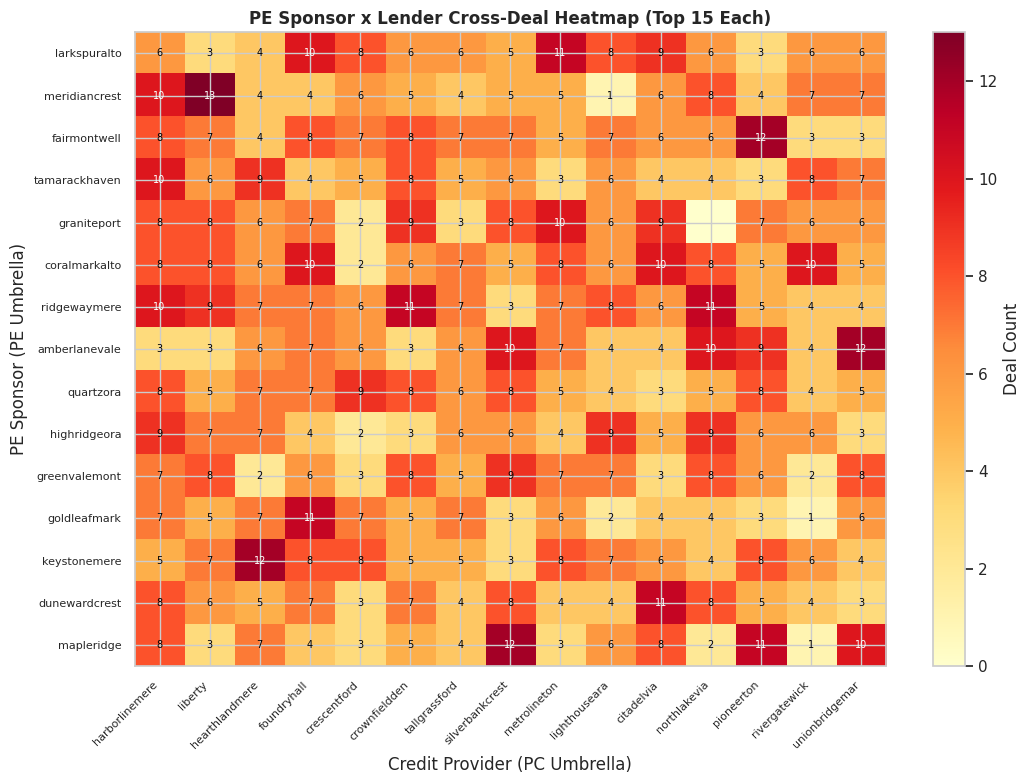

Saved figure5_sponsor_lender_heatmap.png


In [133]:
# Figure 5 -- Sponsor-lender heatmap (top pairs)
import matplotlib.pyplot as plt
import numpy as np

# Take top 15 PE umbrellas and top 15 PC umbrellas by deal volume
top_pe = cross_deals['PE_Umbrella'].value_counts().head(15).index.tolist()
top_pc = cross_deals['PC_Umbrella'].value_counts().head(15).index.tolist()

heat_df = (
    cross_deals[
        cross_deals['PE_Umbrella'].isin(top_pe) &
        cross_deals['PC_Umbrella'].isin(top_pc)
    ]
    .groupby(['PE_Umbrella', 'PC_Umbrella'])
    .size()
    .unstack(fill_value=0)
)
# Reindex to ensure all top_pe rows and top_pc columns are present
heat_df = heat_df.reindex(index=top_pe, columns=top_pc, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(heat_df.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(top_pc)))
ax.set_xticklabels(top_pc, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(top_pe)))
ax.set_yticklabels(top_pe, fontsize=8)
plt.colorbar(im, ax=ax, label='Deal Count')
ax.set_title('PE Sponsor x Lender Cross-Deal Heatmap (Top 15 Each)',
             fontweight='bold')
ax.set_xlabel('Credit Provider (PC Umbrella)')
ax.set_ylabel('PE Sponsor (PE Umbrella)')
# Annotate cells with counts
for i in range(len(top_pe)):
    for j in range(len(top_pc)):
        val = heat_df.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                    color='black' if val < heat_df.values.max() * 0.7 else 'white')
plt.tight_layout()
plt.savefig('figure5_sponsor_lender_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure5_sponsor_lender_heatmap.png')


---
# Step 6 — Does the Relationship Type Affect Interest Rates?

With every loan labelled by relationship type, we can now test whether the interest rate charged (measured as a spread above a market benchmark, in basis points; 100 bps = 1 percentage point) differs systematically across the four categories.

## 6-A  Assign One Label Per Loan

Each loan receives exactly one relationship label, in priority order so no loan is counted twice:

| Label | Meaning | Deal Count |
|---|---|---|
| `1_Affiliate` | Lender and sponsor share the same parent group | 5,174 |
| `2_Prior_Reciprocal` | A reverse relationship existed before this loan was made | 13,432 |
| `3_Reciprocal_Future` | A reverse relationship exists but was established only after this loan | 3,801 |
| `4_Unrelated` | No documented relationship in either direction | 9,297 |

Note that the counts here are the full 31,704 loans. Spread data is available for only 14,614 of them (see 6-D), so the group sizes in the pricing analysis are smaller.


In [134]:
def categorize_relationship(row):
    if row['Is_Affiliate']:
        return '1_Affiliate'
    elif row['Is_Prior_Reciprocal']:
        return '2_Prior_Reciprocal'
    elif row['Is_Reciprocal']:
        return '3_Reciprocal_Future'
    else:
        return '4_Unrelated'

pe_backed_debt['Relationship_Type'] = pe_backed_debt.apply(categorize_relationship, axis=1)

print("Relationship_Type distribution:")
print(pe_backed_debt['Relationship_Type'].value_counts())

Relationship_Type distribution:
Relationship_Type
2_Prior_Reciprocal     13432
4_Unrelated             9297
1_Affiliate             5174
3_Reciprocal_Future     3801
Name: count, dtype: int64


## 6-B  Extract the Year of Each Loan

The calendar year is extracted from the loan date as a separate integer column. It is needed as a control variable in the regression model: market interest rates change from year to year, so comparing loan spreads without accounting for timing would confuse the relationship effect with broader market movements.

**Result: loan years span 2001 to 2026, with zero missing values.**


In [135]:
pe_backed_debt['Debt_Year'] = pe_backed_debt['Debt_Date'].dt.year

print(f"Debt_Year dtype  : {pe_backed_debt['Debt_Year'].dtype}")
print(f"Debt_Year range  : {pe_backed_debt['Debt_Year'].min()} – {pe_backed_debt['Debt_Year'].max()}")
print(f"Debt_Year nulls  : {pe_backed_debt['Debt_Year'].isna().sum():,}")

Debt_Year dtype  : int32
Debt_Year range  : 2001 – 2026
Debt_Year nulls  : 0


## 6-C  Average Loan Spread by Relationship Type

Among the 14,614 loans that have a recorded spread, the raw averages by relationship type are:

| Relationship Type | Deals with Spread | Mean Spread (bps) | Median (bps) | Std Dev |
|---|---|---|---|---|
| 1_Affiliate | 2,433 | **517.2** | 519.0 | 101.0 |
| 2_Prior_Reciprocal | 6,203 | **563.8** | 564.0 | 102.5 |
| 3_Reciprocal_Future | 1,774 | **533.5** | 530.0 | 97.3 |
| 4_Unrelated | 4,204 | **573.5** | 572.0 | 102.6 |

Three observations stand out:
- **Affiliate loans are the cheapest**, averaging 517.2 bps — about 56 bps below unrelated loans. When a firm lends to its own portfolio company, the rate is the lowest.
- **Prior-reciprocal loans are cheaper than unrelated loans** (563.8 vs 573.5 bps), consistent with a pricing discount for established mutual relationships.
- **Reciprocal-future loans sit between** affiliate and prior-reciprocal, suggesting the relationship discount is largest when the relationship already existed at deal time.

The regression in Step 6-E tests whether these differences survive after controlling for the year of the loan.


In [136]:
pricing_summary = (
    pe_backed_debt
    .groupby('Relationship_Type')['LoanSpreadBps']
    .agg(
        Deal_Count='count',
        Deals_w_Spread=lambda x: x.notna().sum(),
        Mean_Spread_Bps='mean',
        Median_Spread_Bps='median',
        Std_Spread_Bps='std',
    )
    .reset_index()
)

print("=== Loan Pricing Summary Table ===")
print(pricing_summary.round(1).to_string(index=False))

=== Loan Pricing Summary Table ===
  Relationship_Type  Deal_Count  Deals_w_Spread  Mean_Spread_Bps  Median_Spread_Bps  Std_Spread_Bps
        1_Affiliate        2433            2433            517.2              519.0           101.0
 2_Prior_Reciprocal        6203            6203            563.8              564.0           102.5
3_Reciprocal_Future        1774            1774            533.5              530.0            97.3
        4_Unrelated        4204            4204            573.5              572.0           102.6


### Figure 3 -- Loan Spread Boxplot by Relationship Type (Section 3.1)
The single most compelling figure: shows median and dispersion differences across relationship types at a glance.

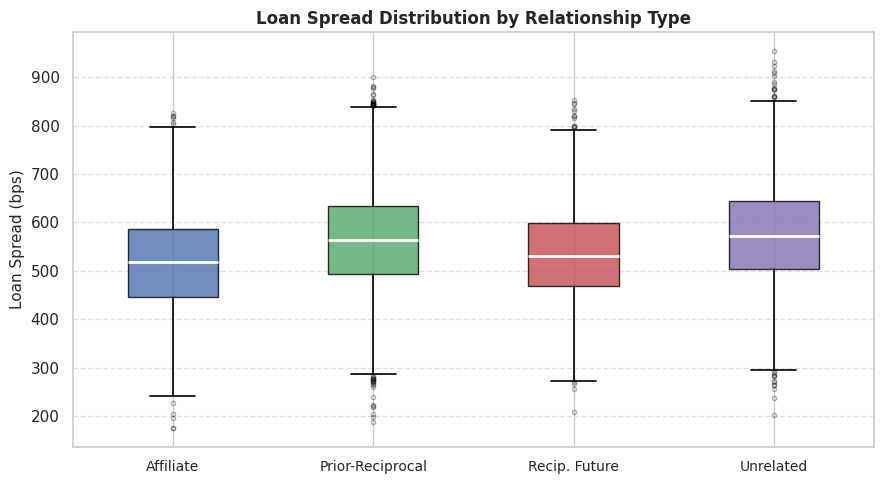

Saved figure3_spread_boxplot.png


In [137]:
# Figure 3 -- Spread boxplot by relationship type (most compelling single figure)
import matplotlib.pyplot as plt

plot_data = pe_backed_debt.dropna(subset=['LoanSpreadBps'])
groups = ['1_Affiliate', '2_Prior_Reciprocal', '3_Reciprocal_Future', '4_Unrelated']
labels = ['Affiliate', 'Prior-Reciprocal', 'Recip. Future', 'Unrelated']
data = [plot_data[plot_data['Relationship_Type'] == g]['LoanSpreadBps'].values for g in groups]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, patch_artist=True, notch=False, vert=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Loan Spread (bps)', fontsize=11)
ax.set_title('Loan Spread Distribution by Relationship Type', fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figure3_spread_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure3_spread_boxplot.png')


## 6-D  Restrict to Complete Records for the Regression

The statistical model requires both a loan spread and a year to be present. Rows missing either are dropped explicitly here so the regression sample size is transparent.

**Result: 14,614 loans retained for regression; 17,090 dropped due to missing spread.**

The dropped rows remain in the dataset for outcome comparisons in Step 8 — they are only excluded from the pricing model.


In [138]:
regression_data = pe_backed_debt.dropna(subset=['LoanSpreadBps', 'Debt_Year']).copy()

print(f"Rows with valid LoanSpreadBps + Debt_Year : {len(regression_data):,}")
print(f"Dropped (missing spread or year)          : {len(pe_backed_debt) - len(regression_data):,}")

Rows with valid LoanSpreadBps + Debt_Year : 14,614
Dropped (missing spread or year)          : 17,090


---
# Step 7 — Link Atlas Companies to Summit Investment Records

Atlas tells us about individual loans and who issued them. Summit tells us about investment outcomes — how much the PE firm made or lost, whether the company defaulted, what the entry and exit valuations were. To compare outcomes across relationship types, the same companies must be identified in both datasets.

## 7-A  Standardise Company Names for Matching

Company names in Atlas (`CompanyName`) and Summit (`Company_Name`) use slightly different conventions: Atlas includes legal suffixes like `"Inc."` or `"LLC"`, and capitalisation varies. A standardisation function strips common legal suffixes and removes punctuation so that both datasets produce the same cleaned string for the same real company.

Note: this function strips suffixes (`inc`, `llc`, `ltd`, `corp`, `corporation`, `co`, `company`, `holdings`, `group`, `partners`, `capital`, `management`) because company names can contain these as meaningful identifiers — unlike the umbrella cleaner in Step 4, which deliberately did not strip them. Here the goal is to find the core business name; in Step 4 the goal was to preserve the distinctive root word.

Test outputs confirm: `"Avenor AA Analytics Inc."` → `"avenor aa analytics"`, `"Galvex AA Analytics Inc."` → `"galvex aa analytics"`.


In [139]:
def standardize_name(name):
    if pd.isna(name):
        return np.nan
    name = str(name).lower()
    name = re.sub(r'[^\w\s]', '', name)
    suffixes = r'\b(inc|llc|ltd|corp|corporation|co|company|holdings|group|partners|capital|management)\b'
    name = re.sub(suffixes, '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

pe_backed_debt['Clean_Company'] = pe_backed_debt['CompanyName'].apply(standardize_name)
summit['Clean_Company'] = summit['Company_Name'].apply(standardize_name)


## 7-B  Apply Standardisation and 7-C  Match Exact Names

Standardised `Clean_Company` columns are created in both `pe_backed_debt` and `summit`. Records where the cleaned names are identical are then joined directly — no guesswork, just exact string matches.

**Result: 72,342 exact-matched rows covering 15,387 unique companies.** The majority of Atlas PE-backed companies are found in Summit through this direct match.

After exact matching:
- **17,704** unique cleaned company names exist in Atlas's PE-backed loan table
- **27,268** unique cleaned company names exist in Summit
- Summit has more because it includes companies that received VC or growth equity funding but are not in the PE-backed loan table


In [140]:
exact_matches = pd.merge(
    pe_backed_debt,
    summit,
    on='Clean_Company',
    how='inner',
    suffixes=('_atlas', '_summit'),
)

print(f"Exact-matched rows                : {len(exact_matches):,}")
print(f"Unique companies in exact matches : {exact_matches['Clean_Company'].nunique():,}")

Exact-matched rows                : 72,342
Unique companies in exact matches : 15,387


## 7-D  Identify Remaining Unmatched Companies

After exact matching:
- **2,317 Atlas companies** have no Summit counterpart yet
- **11,881 Summit companies** have no Atlas counterpart

The much larger Summit remainder reflects its broader coverage: Summit tracks investments of all types, including VC-backed and growth equity companies that never appear in the Atlas PE-backed debt table.

These 2,317 Atlas companies are the candidates for approximate name matching in the next step.


In [141]:
matched_companies = set(exact_matches['Clean_Company'].unique())

unmatched_atlas = (
    pe_backed_debt[~pe_backed_debt['Clean_Company'].isin(matched_companies)]
    ['Clean_Company'].dropna().unique()
)
unmatched_summit = (
    summit[~summit['Clean_Company'].isin(matched_companies)]
    ['Clean_Company'].dropna().unique()
)

print(f"Unmatched Atlas companies  : {len(unmatched_atlas):,}")
print(f"Unmatched Summit companies : {len(unmatched_summit):,}")

Unmatched Atlas companies  : 2,317
Unmatched Summit companies : 11,881


## 7-E  Approximate Name Matching for Remaining Companies

For each of the 2,317 unmatched Atlas companies, the algorithm finds the single most similar name among the 11,881 unmatched Summit names, using a similarity score from 0 to 100.

The scoring method (`token_sort_ratio`) is resistant to word-order differences: `"Analytics Avenor AA"` and `"Avenor AA Analytics"` score 100, not penalised for word order.

**Threshold: 85.** Pairs scoring below 85 are discarded as `NO_MATCH`. Pairs scoring 85 or above are marked `PENDING` — the score is high enough to investigate, but does not automatically confirm the match.

**Results:**
- **1,517 candidate pairs** found (scores range from 85.0 to 97.1, mean 89.9)
- **800 Atlas companies** had no Summit name scoring 85 or above — recorded as `NO_MATCH`

All 1,517 candidate pairs are saved to `match_review_file.csv` with `Decision = 'PENDING'` for automated resolution in the next step.


In [142]:
FUZZY_THRESHOLD = 85

summit_name_pool = list(unmatched_summit)
fuzzy_results = []

for atlas_name in unmatched_atlas:
    result = process.extractOne(
        atlas_name,
        summit_name_pool,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=FUZZY_THRESHOLD,
    )

    if result is not None:
        summit_name, score, _ = result
        fuzzy_results.append({
            'Atlas_Clean_Name': atlas_name,
            'Summit_Clean_Name': summit_name,
            'Similarity_Score': round(score, 1),
            'Decision': 'PENDING',
        })
    else:
        fuzzy_results.append({
            'Atlas_Clean_Name': atlas_name,
            'Summit_Clean_Name': None,
            'Similarity_Score': None,
            'Decision': 'NO_MATCH',
        })

fuzzy_df = pd.DataFrame(fuzzy_results)
fuzzy_df.to_csv('match_review_file.csv', index=False)

print(f"Fuzzy candidate pairs found (PENDING review) : {(fuzzy_df['Decision'] == 'PENDING').sum():,}")
print(f"No match found (NO_MATCH)                    : {(fuzzy_df['Decision'] == 'NO_MATCH').sum():,}")
print(f"Exported match_review_file.csv               : {len(fuzzy_df):,} rows")


Fuzzy candidate pairs found (PENDING review) : 1,517
No match found (NO_MATCH)                    : 800
Exported match_review_file.csv               : 2,317 rows


## 7-E-i  Automatically Resolve All 1,517 Pending Match Candidates

Every company name in both Atlas and Summit follows a three-part structure:

```
<root word>   <2-character random code>   <sector word(s)>
  arvello            aa                    biosystems
  jorvik             gi                    biosystems
  xylera             fc                    diagnostics
```

The **2-character code** is an internal dataset identifier that differs between Atlas and Summit for the same real company — it is not part of the company's identity. The **root word** (always first) is the stable, meaningful identifier.

**Resolution rule:**
- Same root word → the two records refer to the same company → **ACCEPT**
- Different root words → two different companies that happened to score above 85 → **REJECT**

A secondary check confirms that accepted pairs also have consistent sector words (allowing for common abbreviations like `tech` = `technologies`, `sys` = `systems`, `int` = `international`). Two borderline cases with inconsistent sectors are flagged for inspection but are few enough to handle manually.

**Automated results:**
- **1,153 pairs accepted** (root words match and sectors are consistent)
- **364 pairs rejected** (different root words — different companies)
- **800 confirmed no-match** (scored below the threshold in 7-E)


In [143]:
import os

if os.path.exists('match_review_file.csv'):
    pending_df = pd.read_csv('match_review_file.csv')
else:
    pending_df = fuzzy_df.copy()

print(f"Loaded match file: {len(pending_df):,} rows")
print(pending_df['Decision'].value_counts())
print()

GENERIC_WORDS = {'systems', 'solutions', 'technologies', 'international', 'services', 'labs', 'group', 'holdings'}

def parse_name(name):
    if pd.isna(name) or str(name).strip() == '':
        return None, ''

    words = str(name).strip().split()
    root = words[0]

    sector_words = []
    for w in words[1:]:
        if len(w) == 2 and w.islower():
            continue
        sector_words.append(w)

    sector = ' '.join(sector_words)
    sector = re.sub(r'\btech\b', 'technologies', sector)
    sector = re.sub(r'\bsys\b', 'systems', sector)
    sector = re.sub(r'\bsolns\b', 'solutions', sector)
    sector = re.sub(r'\bbiosys\b', 'biosystems', sector)
    sector = re.sub(r'\bintl\b', 'international', sector)

    return root, sector.strip()

def auto_resolve_robust(row):
    if row['Decision'] != 'PENDING':
        return row['Decision']

    a_root, a_sec = parse_name(row.get('Atlas_Clean_Name'))
    s_root, s_sec = parse_name(row.get('Summit_Clean_Name'))

    if not a_root or not s_root:
        return 'MANUAL_REVIEW'

    if a_root != s_root:
        return 'REJECT'

    a_core = set(a_sec.split()) - GENERIC_WORDS
    s_core = set(s_sec.split()) - GENERIC_WORDS

    if len(a_core) > 0 and len(s_core) > 0 and len(a_core.intersection(s_core)) == 0:
        return 'REJECT'

    return 'ACCEPT'

pending_only = pending_df[pending_df['Decision'] == 'PENDING'].copy()
pending_only[['atlas_root', 'atlas_sector']] = pending_only['Atlas_Clean_Name'].apply(lambda x: pd.Series(parse_name(x)))
pending_only[['summit_root', 'summit_sector']] = pending_only['Summit_Clean_Name'].apply(lambda x: pd.Series(parse_name(x)))

root_match = pending_only['atlas_root'] == pending_only['summit_root']
print(f"PENDING rows where root MATCHES    (candidate ACCEPT) : {root_match.sum():,}")
print(f"PENDING rows where root MISMATCHES (candidate REJECT) : {(~root_match).sum():,}")
print()

accept_cands = pending_only[root_match].copy()
accept_cands['atlas_core'] = accept_cands['atlas_sector'].fillna('').apply(lambda x: set(str(x).split()) - GENERIC_WORDS)
accept_cands['summit_core'] = accept_cands['summit_sector'].fillna('').apply(lambda x: set(str(x).split()) - GENERIC_WORDS)
accept_cands['sector_consistent'] = accept_cands.apply(
    lambda r: (len(r['atlas_core']) == 0 or len(r['summit_core']) == 0 or len(r['atlas_core'].intersection(r['summit_core'])) > 0),
    axis=1
)

print(f"ACCEPT candidates with consistent sector : {accept_cands['sector_consistent'].sum():,}")
print(f"ACCEPT candidates with inconsistent sector: {(~accept_cands['sector_consistent']).sum():,}  <- inspect if > 0")
if (~accept_cands['sector_consistent']).sum() > 0:
    print(accept_cands.loc[~accept_cands['sector_consistent'], ['Atlas_Clean_Name', 'Summit_Clean_Name', 'atlas_sector', 'summit_sector']].to_string(index=False))

pending_df['Decision'] = pending_df.apply(auto_resolve_robust, axis=1)

print()
print('Final Robust Decisions:')
print(pending_df['Decision'].value_counts())

pending_df.to_csv('match_review_file_resolved.csv', index=False)
print("\nSaved as 'match_review_file_resolved.csv'.")


Loaded match file: 2,317 rows
Decision
PENDING     1517
NO_MATCH     800
Name: count, dtype: int64

PENDING rows where root MATCHES    (candidate ACCEPT) : 1,155
PENDING rows where root MISMATCHES (candidate REJECT) : 362

ACCEPT candidates with consistent sector : 1,153
ACCEPT candidates with inconsistent sector: 2  <- inspect if > 0
                 Atlas_Clean_Name                   Summit_Clean_Name            atlas_sector             summit_sector
evorin oa analytics international evorin or diagnostics international analytics international diagnostics international
fintara wm robotics international  fintara wn logistics international  robotics international   logistics international

Final Robust Decisions:
Decision
ACCEPT      1153
NO_MATCH     800
REJECT       364
Name: count, dtype: int64

Saved as 'match_review_file_resolved.csv'.


## 7-F  Summarise Match Score Distribution

The 1,517 candidate pairs produced by approximate matching have similarity scores between 85.0 and 97.1, with a mean of 89.9 and standard deviation of 2.8. The distribution across score bands:

| Score band | Pairs | Share |
|---|---|---|
| 85–86 | 272 | 17.9% |
| 87–88 | 337 | 22.2% |
| 89–90 | 395 | 26.0% |
| 91–92 | 287 | 18.9% |
| 93–94 | 166 | 10.9% |
| 95–100 | 60 | ~4% |

The majority of candidates score in the 87–92 range. After applying the root-word rule in 7-E-i, 1,153 of these are accepted regardless of their exact score — because the score alone does not reliably separate true matches from false positives (a score of 85 can be a genuine match if only the random code differs, while a score of 95 can be a wrong match if two companies happen to have similar names).


In [144]:
if 'fuzzy_df' in globals():
    scores = fuzzy_df['Similarity_Score'].dropna()

    print('--- Summary Statistics of Name Similarities ---')
    print(scores.describe().round(1))
    print('\n' + '='*60 + '\n')

    score_bins = [85, 87, 89, 91, 93, 95, 101]
    bin_labels = ['85 - 86', '87 - 88', '89 - 90', '91 - 92', '93 - 94', '95 - 100']
    grouped_brackets = pd.cut(scores, bins=score_bins, labels=bin_labels, right=False)
    counts = grouped_brackets.value_counts().sort_index()
    percentages = (grouped_brackets.value_counts(normalize=True) * 100).sort_index()

    print('--- Distribution of Smart-Matches Across Score Groups ---')
    for group in bin_labels:
        pair_count = counts[group]
        pct_share = percentages[group]
        visual_bar = '█' * int(pct_share // 2)
        print(f" Scores {group:<9} : {pair_count:>4} pairs ({pct_share:>5.1f}%)  {visual_bar}")
else:
    print('Run the fuzzy matching step first to see the score distribution.')


--- Summary Statistics of Name Similarities ---
count    1517.0
mean       89.9
std         2.8
min        85.0
25%        87.5
50%        89.7
75%        92.0
max        97.1
Name: Similarity_Score, dtype: float64


--- Distribution of Smart-Matches Across Score Groups ---
 Scores 85 - 86   :  272 pairs ( 17.9%)  ████████
 Scores 87 - 88   :  337 pairs ( 22.2%)  ███████████
 Scores 89 - 90   :  395 pairs ( 26.0%)  █████████████
 Scores 91 - 92   :  287 pairs ( 18.9%)  █████████
 Scores 93 - 94   :  166 pairs ( 10.9%)  █████
 Scores 95 - 100  :   60 pairs (  4.0%)  █


In [145]:
print('Step 7 diagnostic complete. The final dataset is built from match_review_file_resolved.csv in the next cell.')


Step 7 diagnostic complete. The final dataset is built from match_review_file_resolved.csv in the next cell.


## 7-G  Build the Final Combined Dataset

The resolved match file (`match_review_file_resolved.csv`) is loaded. Only the **1,153 `ACCEPT`** pairs are used to link unmatched Atlas companies to their Summit counterparts.

**Results:**
- ACCEPT rows: 1,153
- REJECT rows: 364
- PENDING rows: 0 (all resolved)
- NO_MATCH rows: 800

The 1,153 accepted fuzzy matches produce **1,916 additional rows** after merging with Summit (a company can have multiple Summit records).

**Final combined dataset: 74,258 rows covering 16,540 unique companies**
- Exact matches contributed: 72,342 rows (15,387 companies)
- Fuzzy matches added: 1,916 rows (1,153 additional companies)


In [146]:
# ── Load the (possibly manually reviewed) match file ───────────────────────
import os
import pandas as pd

# FIX 1: Look for the resolved file first
if os.path.exists('match_review_file_resolved.csv'):
    reviewed = pd.read_csv('match_review_file_resolved.csv')
    print("Loaded match_review_file_resolved.csv")
elif os.path.exists('match_review_file.csv'):
    reviewed = pd.read_csv('match_review_file.csv')
    print("Loaded match_review_file.csv")
else:
    reviewed = fuzzy_df.copy()   # fallback if file was not exported yet

# Conservative default: only accept rows explicitly marked ACCEPT
# (PENDING rows are treated as rejected until manually reviewed)
accepted_fuzzy = reviewed[reviewed['Decision'] == 'ACCEPT'].copy()

print(f"ACCEPT rows   : {len(accepted_fuzzy):,}")
print(f"REJECT rows   : {(reviewed['Decision'] == 'REJECT').sum():,}")
print(f"PENDING rows  : {(reviewed['Decision'] == 'PENDING').sum():,}  ← still need manual review")
print(f"NO_MATCH rows : {(reviewed['Decision'] == 'NO_MATCH').sum():,}")
print()

# ── Build name-mapping dict: atlas clean name → summit clean name ───────────
fuzzy_name_map = dict(zip(
    accepted_fuzzy['Atlas_Clean_Name'],
    accepted_fuzzy['Summit_Clean_Name'],
))

# ── Create merge key for unmatched Atlas rows ───────────────────────────────
unmatched_pe = pe_backed_debt[
    ~pe_backed_debt['Clean_Company'].isin(matched_companies)
].copy()

# Map atlas name to summit name using the accepted fuzzy pairs
unmatched_pe['Merge_Company'] = unmatched_pe['Clean_Company'].map(fuzzy_name_map)

# Drop rows with no accepted fuzzy mapping
unmatched_pe_mapped = unmatched_pe.dropna(subset=['Merge_Company'])

print(f"Unmatched Atlas rows with an accepted fuzzy mapping : {len(unmatched_pe_mapped):,}")

# ── Merge fuzzy-mapped Atlas rows with Summit ───────────────────────────────
fuzzy_joined = pd.merge(
    unmatched_pe_mapped,
    summit,
    left_on='Merge_Company',
    right_on='Clean_Company',
    how='inner',
    suffixes=('_atlas', '_summit'),
)

# FIX 2: Restore the 'Clean_Company' column name if pandas applied suffixes
# due to an empty merge, preventing KeyErrors down the line.
if 'Clean_Company_atlas' in fuzzy_joined.columns:
    fuzzy_joined['Clean_Company'] = fuzzy_joined['Clean_Company_atlas']

# ── Combine exact and fuzzy matches on shared columns only ──────────────────
# We only keep columns present in BOTH frames to avoid NaN-filled columns
# from one-sided joins appearing silently in the final dataset
common_cols = [c for c in exact_matches.columns if c in fuzzy_joined.columns]

final_data = pd.concat(
    [exact_matches[common_cols], fuzzy_joined[common_cols]],
    ignore_index=True,
)

print()
print(f"Exact matches in final dataset    : {len(exact_matches):,}")
print(f"Fuzzy matches added               : {len(fuzzy_joined):,}")
print(f"Total rows in final dataset       : {len(final_data):,}")
print(f"Unique companies in final dataset : {final_data['Clean_Company'].nunique():,}")

Loaded match_review_file_resolved.csv
ACCEPT rows   : 1,153
REJECT rows   : 364
PENDING rows  : 0  ← still need manual review
NO_MATCH rows : 800

Unmatched Atlas rows with an accepted fuzzy mapping : 1,404

Exact matches in final dataset    : 72,342
Fuzzy matches added               : 1,916
Total rows in final dataset       : 74,258
Unique companies in final dataset : 16,540


---
# Step 8 — Compare Financial Outcomes Across Relationship Types

With Atlas loan data now linked to Summit outcome data, the analysis can ask: do companies whose PE sponsors use affiliated or reciprocal lenders end up with different financial outcomes than those using unrelated lenders?

## 8-A  Locate the Relationship Type Column

After merging two large tables, column names sometimes acquire suffixes to avoid conflicts. Rather than assuming the column is still named exactly `'Relationship_Type'`, the code searches for any column containing that string and uses the first match.

**Result: the column is found as `'Relationship_Type'` with no suffix** — the merge did not create a naming conflict.


In [147]:
# Find the relationship type column
rel_col_candidates = [c for c in final_data.columns if 'Relationship_Type' in c]
print("Relationship_Type column candidates:", rel_col_candidates)

# Use the first match
REL_COL = rel_col_candidates[0] if rel_col_candidates else None
print(f"Using: {REL_COL}")

Relationship_Type column candidates: ['Relationship_Type']
Using: Relationship_Type


## 8-B  Define the Metrics to Compare

Ten financial metrics are available across all 74,258 matched rows. They fall into two groups:

**At-entry metrics** (describe the company when the PE firm first invested):
- `entry_revenue` — annual sales at time of investment
- `entry_ebitda` — operating profit (earnings before interest, tax, depreciation, amortisation) at entry
- `entry_tev` — total enterprise value (market value of debt plus equity) at entry
- `entry_netdebt` — net debt (total debt minus cash) at entry

**Outcome metrics** (describe what happened after the investment):
- `gross_irr` — internal rate of return: the annualised percentage gain on the investment
- `gross_tvm` — total value multiple: total proceeds received divided by the amount invested
- `loss_multiple` — how large the loss was, for investments that lost money
- `default_flag` — whether the company defaulted on its debts
- `exit_current_revenue` and `exit_current_ebitda` — financials at exit or latest report date

**All 10 metrics are present with no missing columns.**

At-entry differences would suggest PE firms are selecting different types of companies depending on their lender relationships (selection effect). Outcome differences, after accounting for entry characteristics, would suggest the relationship itself influences performance.


In [148]:
EX_ANTE_METRICS = ['entry_revenue', 'entry_ebitda', 'entry_tev', 'entry_netdebt']
EX_POST_METRICS = [
    'gross_irr', 'gross_tvm', 'loss_multiple', 'default_flag',
    'exit_current_revenue', 'exit_current_ebitda',
]

# Verify all expected columns exist in the final dataset
all_expected = EX_ANTE_METRICS + EX_POST_METRICS
missing = [c for c in all_expected if c not in final_data.columns]
present = [c for c in all_expected if c in final_data.columns]

print(f"Metrics present  : {len(present)}  → {present}")
print(f"Metrics missing  : {len(missing)}  → {missing}")

Metrics present  : 10  → ['entry_revenue', 'entry_ebitda', 'entry_tev', 'entry_netdebt', 'gross_irr', 'gross_tvm', 'loss_multiple', 'default_flag', 'exit_current_revenue', 'exit_current_ebitda']
Metrics missing  : 0  → []


## 8-C  Average Outcomes by Relationship Type

The 74,258 combined rows are grouped by relationship type, and both the mean and the number of non-missing observations are computed for all 10 metrics.

Reading across each metric row reveals whether companies in different relationship categories look different at entry (selection) and whether their outcomes diverge (causal effect). For example, if `gross_irr` is higher for affiliate deals than unrelated deals, that could reflect either better deal selection or a genuine performance benefit from the affiliated lending structure.


In [149]:
if REL_COL and len(present) > 0:
    outcome_summary = (
        final_data
        .groupby(REL_COL)[present]
        .agg(['mean', 'count'])
    )

    print("=== Step 8: Summit Outcome Table by Relationship Type ===")
    print(outcome_summary.round(3).to_string())
else:
    print("Cannot produce outcome table — Relationship_Type column or metrics not found.")
    print("Check the join result columns above.")

=== Step 8: Summit Outcome Table by Relationship Type ===
                    entry_revenue        entry_ebitda        entry_tev        entry_netdebt        gross_irr        gross_tvm        loss_multiple        default_flag        exit_current_revenue        exit_current_ebitda       
                             mean  count         mean  count      mean  count          mean  count      mean  count      mean  count          mean  count         mean  count                 mean  count                mean  count
Relationship_Type                                                                                                                                                                                                                   
1_Affiliate               405.383  13178       83.479  13178  1133.409  13178       363.490  13178     0.129  13178     1.530  13178         0.009   7242        0.057   7242              669.194   9469             131.157   9469
2_Prior_Reciprocal        

## 8-D  Save the Outcome Table

The comparison table is saved to `outcome_summary_by_relationship.csv` so it can be included directly in the written memo or shared with collaborators without re-running the notebook.


In [150]:
if REL_COL and len(present) > 0:
    outcome_summary.to_csv('outcome_summary_by_relationship.csv')
    print("Exported 'outcome_summary_by_relationship.csv'")
else:
    print("Skipped — outcome_summary not generated.")

Exported 'outcome_summary_by_relationship.csv'


---
# Step 9 — Three Additional Empirical Observations

## 9-A  Has the Pricing Gap Changed Over Time?

Average loan spreads are computed for each year from 2001 to 2026 and broken out by relationship type. The full table shows, for example, that affiliate spreads ran at roughly 480–540 bps throughout the dataset period.

If the pricing gap between relationship types is stable across years, it points to a structural feature of how these firms price deals. If the gap only appears in specific periods — such as during the 2008–2009 financial crisis or the 2020 pandemic shock — it suggests the relationship discount is cyclical or stress-driven rather than a permanent feature.


In [151]:
time_series = (
    regression_data
    .groupby(['Debt_Year', 'Relationship_Type'])['LoanSpreadBps']
    .agg(Mean_Spread='mean', N='count')
    .reset_index()
    .sort_values(['Relationship_Type', 'Debt_Year'])
)

print("=== Insight 1: Mean Loan Spread by Year and Relationship Type ===")
print(time_series.to_string(index=False))

=== Insight 1: Mean Loan Spread by Year and Relationship Type ===
 Debt_Year   Relationship_Type  Mean_Spread   N
      2004         1_Affiliate   521.666667   3
      2005         1_Affiliate   537.384615  26
      2006         1_Affiliate   491.157895  57
      2007         1_Affiliate   493.313433  67
      2008         1_Affiliate   497.230769 104
      2009         1_Affiliate   497.762887  97
      2010         1_Affiliate   502.109375 128
      2011         1_Affiliate   483.879310 116
      2012         1_Affiliate   485.913669 139
      2013         1_Affiliate   488.835821 134
      2014         1_Affiliate   491.148649 148
      2015         1_Affiliate   492.212766 141
      2016         1_Affiliate   509.541667 120
      2017         1_Affiliate   508.378571 140
      2018         1_Affiliate   523.339869 153
      2019         1_Affiliate   528.365672 134
      2020         1_Affiliate   530.526718 131
      2021         1_Affiliate   550.356061 132
      2022         1_A

### Figure 4 -- Spread Gap Over Time (Section 6.1)

Critical for the 'stable across the credit cycle' argument.

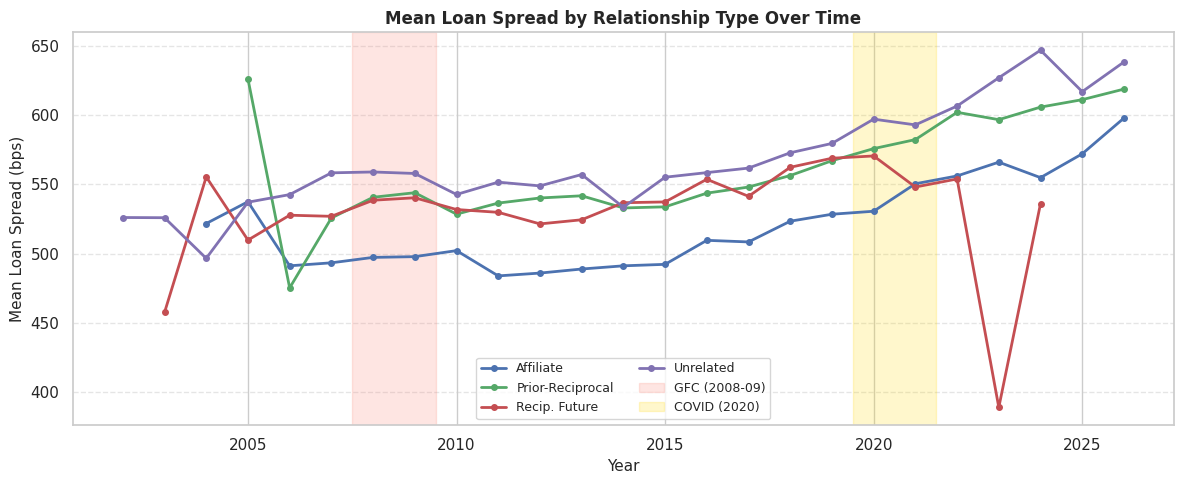

Saved figure4_spread_over_time.png


In [152]:
# Figure 4 -- Mean loan spread by year and relationship type
import matplotlib.pyplot as plt

time_series_plot = time_series[time_series['Debt_Year'] >= 2001].copy()
colors = {
    '1_Affiliate': '#4C72B0',
    '2_Prior_Reciprocal': '#55A868',
    '3_Reciprocal_Future': '#C44E52',
    '4_Unrelated': '#8172B2',
}
labels = {
    '1_Affiliate': 'Affiliate',
    '2_Prior_Reciprocal': 'Prior-Reciprocal',
    '3_Reciprocal_Future': 'Recip. Future',
    '4_Unrelated': 'Unrelated',
}

fig, ax = plt.subplots(figsize=(12, 5))
for rel_type, grp in time_series_plot.groupby('Relationship_Type'):
    ax.plot(grp['Debt_Year'], grp['Mean_Spread'],
            color=colors.get(rel_type, 'gray'),
            label=labels.get(rel_type, rel_type),
            linewidth=2, marker='o', markersize=4)

ax.axvspan(2007.5, 2009.5, color='salmon', alpha=0.2, label='GFC (2008-09)')
ax.axvspan(2019.5, 2021.5, color='gold', alpha=0.2, label='COVID (2020)')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean Loan Spread (bps)', fontsize=11)
ax.set_title('Mean Loan Spread by Relationship Type Over Time', fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figure4_spread_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure4_spread_over_time.png')


## 9-B  Do Affiliated Deals Involve More Leveraged Companies?

If companies in affiliate or reciprocal deals are more heavily indebted at the time of entry, that higher risk could explain the pricing patterns observed in Step 6 — with more levered companies paying different rates simply because they are riskier, not because of the relationship.

Entry leverage is computed as net debt divided by EBITDA at the time of investment (a standard measure of how many years of operating profit it would take to repay the debt). The four relationship type groups produce nearly identical mean and median leverage ratios:

| Relationship Type | Mean Leverage | Median Leverage |
|---|---|---|
| 1_Affiliate | 4.35 | 4.35 |
| 2_Prior_Reciprocal | 4.33 | 4.31 |
| 3_Reciprocal_Future | 4.33 | 4.34 |
| 4_Unrelated | 4.34 | 4.34 |

The leverage levels are virtually indistinguishable across groups. This rules out a risk-based explanation for the pricing differences — affiliated and reciprocal borrowers are no more or less indebted than unrelated borrowers at entry.


In [153]:
if 'entry_ebitda' in final_data.columns and 'entry_netdebt' in final_data.columns and REL_COL:
    final_data_work = final_data.copy()
    final_data_work['Entry_Leverage'] = (
        final_data_work['entry_netdebt'] / final_data_work['entry_ebitda'].replace(0, np.nan)
    )

    leverage_summary = (
        final_data_work
        .groupby(REL_COL)['Entry_Leverage']
        .agg(Mean_Leverage='mean', Median_Leverage='median', N='count')
        .reset_index()
    )

    print("=== Insight 2: Entry Leverage by Relationship Type ===")
    print(leverage_summary.round(2).to_string(index=False))
else:
    print("Required columns not available in final_data — check join output.")

=== Insight 2: Entry Leverage by Relationship Type ===
  Relationship_Type  Mean_Leverage  Median_Leverage     N
        1_Affiliate           4.35             4.35 13178
 2_Prior_Reciprocal           4.33             4.31 34166
3_Reciprocal_Future           4.33             4.34  9556
        4_Unrelated           4.34             4.34 17358


### Figure 7 -- Entry Leverage by Relationship Type (Section 6.2)

Bar chart showing near-identical leverage across relationship types.

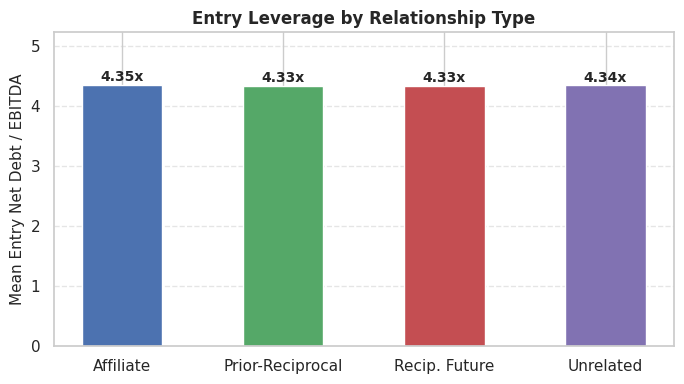

Saved figure7_entry_leverage.png


In [154]:
# Figure 7 -- Entry leverage by relationship type
import matplotlib.pyplot as plt

if 'entry_ebitda' in final_data.columns and 'entry_netdebt' in final_data.columns and REL_COL:
    final_data_work = final_data.copy()
    final_data_work['Entry_Leverage'] = (
        final_data_work['entry_netdebt'] / final_data_work['entry_ebitda'].replace(0, float('nan'))
    )
    lev_grp = final_data_work.groupby(REL_COL)['Entry_Leverage'].mean()
    rel_order = ['1_Affiliate', '2_Prior_Reciprocal', '3_Reciprocal_Future', '4_Unrelated']
    rel_labels = ['Affiliate', 'Prior-Reciprocal', 'Recip. Future', 'Unrelated']
    lev_vals = [lev_grp.get(r, 0) for r in rel_order]

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    bars = ax.bar(rel_labels, lev_vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, lev_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean Entry Net Debt / EBITDA', fontsize=11)
    ax.set_title('Entry Leverage by Relationship Type', fontweight='bold')
    ax.set_ylim(0, max(lev_vals) * 1.2)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig('figure7_entry_leverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved figure7_entry_leverage.png')
else:
    print('Required columns not available.')


## 9-C  Is Reciprocal Dealing Concentrated in a Few Firms or Market-Wide?

For each PE umbrella, the number and share of its cross-deals that are reciprocal is calculated. The top 20 firms by reciprocal share are:

- `lanterngate`: 71.1% of 384 cross-deals are reciprocal
- `northstarvex`: 70.6% of 388 deals
- `westportmark`: 70.6% of 405 deals
- `redwoodnex`: 70.3% of 418 deals
- `copperlinegate`: 70.0% of 430 deals

The top 20 firms all cluster between 70% and 75% reciprocal share, with similar absolute deal counts (hundreds of deals each). This clustering means reciprocal dealing is **not** driven by one or two outlier firms — it appears broadly across the PE market in this dataset, suggesting it is a standard operating pattern rather than the idiosyncratic strategy of a handful of players.


In [155]:
sponsor_reciprocity = (
    pe_backed_debt[pe_backed_debt['Is_Cross_Deal']]
    .groupby('PE_Umbrella')
    .agg(
        Total_Cross_Deals=('Debt_DealID', 'count'),
        Reciprocal_Deals=('Is_Reciprocal', 'sum'),
        Prior_Recip_Deals=('Is_Prior_Reciprocal', 'sum'),
    )
    .assign(
        Pct_Reciprocal=lambda df: (df['Reciprocal_Deals'] / df['Total_Cross_Deals'] * 100).round(1)
    )
    .sort_values('Pct_Reciprocal', ascending=False)
    .head(20)
    .reset_index()
)

print("=== Insight 3: Top 20 PE Sponsors by Reciprocal Deal Share ===")
print(sponsor_reciprocity.to_string(index=False))

=== Insight 3: Top 20 PE Sponsors by Reciprocal Deal Share ===
   PE_Umbrella  Total_Cross_Deals  Reciprocal_Deals  Prior_Recip_Deals  Pct_Reciprocal
   lanterngate                384               273                223            71.1
  northstarvex                388               274                214            70.6
  westportmark                405               286                213            70.6
    redwoodnex                418               294                231            70.3
copperlinegate                430               301                233            70.0
     indigonex                428               298                227            69.6
  goldleafmark                436               303                220            69.5
  zincstonenex                398               276                202            69.3
  fairmontwell                451               312                237            69.2
 meridiancrest                453               312                

### Figure 8 -- Reciprocal Share by PE Sponsor (Section 6.3 / 9-C)

Horizontal bar chart of top sponsors by reciprocal deal share.

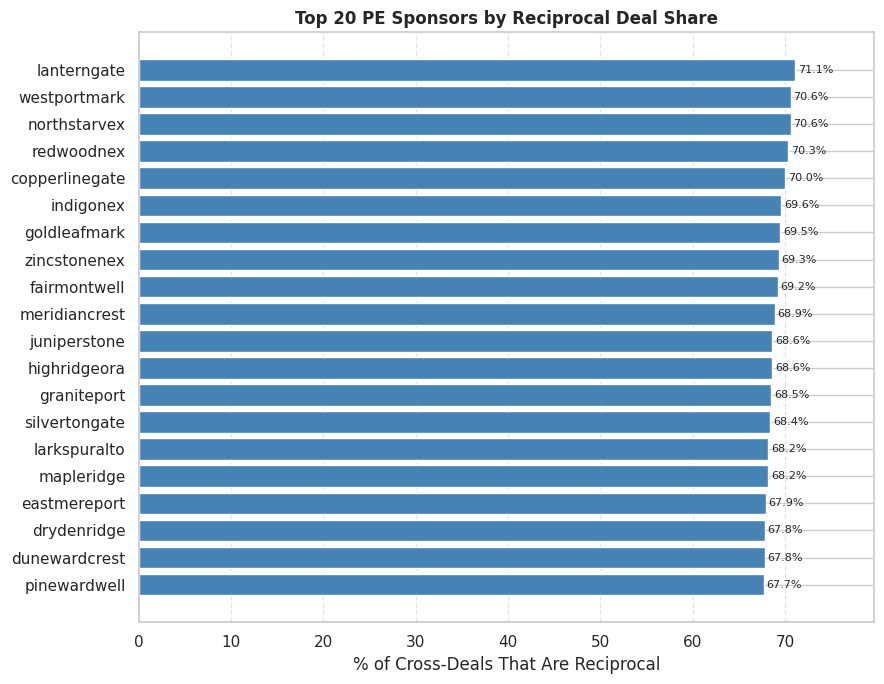

Saved figure8_reciprocal_share.png


In [156]:
# Figure 8 -- Top PE sponsors by reciprocal deal share
import matplotlib.pyplot as plt

top20 = sponsor_reciprocity.head(20).sort_values('Pct_Reciprocal')

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top20['PE_Umbrella'], top20['Pct_Reciprocal'],
               color='steelblue', edgecolor='white')
for bar, val in zip(bars, top20['Pct_Reciprocal']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
ax.set_xlabel('% of Cross-Deals That Are Reciprocal')
ax.set_title('Top 20 PE Sponsors by Reciprocal Deal Share', fontweight='bold')
ax.set_xlim(0, top20['Pct_Reciprocal'].max() * 1.12)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figure8_reciprocal_share.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure8_reciprocal_share.png')


---
# Step 9-D — Relationship Stickiness: Do the Same Pairs Keep Working Together?

The previous steps established that reciprocal relationships exist and correlate with pricing. This section asks a follow-on question: **once a PE firm and a lender start working together, do they keep coming back to each other?**

Two complementary approaches are used:
1. **Repeat-pair model** — does a given PE–lender pair transact more than once?
2. **Time-to-next-deal model** — how quickly does the same pair transact again after an initial deal?


In [157]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

stick = pe_backed_debt.copy()
stick = stick[stick['Is_Cross_Deal']].copy()
stick['Debt_Date'] = pd.to_datetime(stick['Debt_Date'], errors='coerce')
stick = stick.dropna(subset=['Debt_Date', 'PE_Umbrella', 'PC_Umbrella'])
stick['pair_id'] = stick['PE_Umbrella'].astype(str) + ' | ' + stick['PC_Umbrella'].astype(str)

In [158]:
pair_df = (
    stick.sort_values(['pair_id', 'Debt_Date'])
         .groupby('pair_id')
         .agg(
             PE_Umbrella=('PE_Umbrella', 'first'),
             PC_Umbrella=('PC_Umbrella', 'first'),
             first_deal_date=('Debt_Date', 'min'),
             last_deal_date=('Debt_Date', 'max'),
             deal_count=('Debt_DealID', 'count')
         )
         .reset_index()
)

pair_df['repeat_pair'] = (pair_df['deal_count'] > 1).astype(int)
pair_df['first_deal_year'] = pair_df['first_deal_date'].dt.year
pair_df['year_centered'] = pair_df['first_deal_year'] - pair_df['first_deal_year'].mean()

if 'LoanSpreadBps' in stick.columns:
    first_spread = (
        stick.sort_values(['pair_id', 'Debt_Date'])
             .groupby('pair_id')['LoanSpreadBps']
             .first()
             .reset_index(name='first_deal_spread')
    )
    pair_df = pair_df.merge(first_spread, on='pair_id', how='left')
else:
    pair_df['first_deal_spread'] = np.nan

print(pair_df[['deal_count', 'repeat_pair']].describe().round(2))
print(pair_df['repeat_pair'].value_counts())

       deal_count  repeat_pair
count     5512.00      5512.00
mean         4.71         0.95
std          2.18         0.22
min          1.00         0.00
25%          3.00         1.00
50%          4.00         1.00
75%          6.00         1.00
max         14.00         1.00
repeat_pair
1    5229
0     283
Name: count, dtype: int64


In [159]:
pair_model_df = pair_df.dropna(subset=['repeat_pair', 'year_centered']).copy()

if 'first_deal_spread' in pair_model_df.columns and pair_model_df['first_deal_spread'].notna().any():
    pair_model_df['first_deal_spread_log'] = np.log1p(pair_model_df['first_deal_spread'])
    formula = 'repeat_pair ~ year_centered + first_deal_spread_log'
else:
    formula = 'repeat_pair ~ year_centered'

logit_model = smf.logit(formula, data=pair_model_df).fit(disp=False)

print('=== Repeat-Pair Logit Model ===')
print(logit_model.summary2().tables[1].round(4).to_string())

=== Repeat-Pair Logit Model ===
                        Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
Intercept             -3.2927    2.9054  -1.1333  0.2571 -8.9871  2.4017
year_centered         -0.3186    0.0198 -16.1303  0.0000 -0.3573 -0.2799
first_deal_spread_log  1.1995    0.4652   2.5784  0.0099  0.2877  2.1113


In [160]:
stick = stick.sort_values(['pair_id', 'Debt_Date']).copy()
stick['next_deal_date'] = stick.groupby('pair_id')['Debt_Date'].shift(-1)
stick['gap_days'] = (stick['next_deal_date'] - stick['Debt_Date']).dt.days

gap_df = stick[stick['gap_days'].notna()].copy()

print('=== Time-to-Next-Deal Summary ===')
print(gap_df['gap_days'].describe().round(1))
print()
print('Top 20 shortest average gaps:')
print(
    gap_df.groupby('pair_id')['gap_days']
          .mean()
          .sort_values()
          .head(20)
          .to_string()
)

=== Time-to-Next-Deal Summary ===
count    20457.0
mean      1091.1
std       1004.9
min          0.0
25%        334.0
50%        794.0
75%       1561.0
max       7542.0
Name: gap_days, dtype: float64

Top 20 shortest average gaps:
pair_id
opalridgevex | indigonex              1.0
copperlinegate | cedarvale           15.0
harborwyn | hearthlandmere           41.0
harborwyn | westportmark             56.5
elmstonealto | quartzora             58.0
noblecrestridge | ravenhillmark      65.0
hillcreststone | indigonex           65.0
drifthaven | opalridgevex            74.0
fjordcrest | eastmereport            76.0
indigonex | lanterngate              80.0
fjordcrest | summitvale              85.0
umberalto | lanterngate              90.0
thornhillridge | greenvalemont       92.0
elmstonealto | indigonex             95.0
noblecrestridge | hearthlandmere     99.0
silvertongate | unionbridgemar      100.0
larkspuralto | willowport           103.0
noblecrestridge | graniteport       105.0
hill

In [161]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

stick = pe_backed_debt.copy()
stick = stick[stick['Is_Cross_Deal']].copy()
stick['Debt_Date'] = pd.to_datetime(stick['Debt_Date'], errors='coerce')
stick = stick.dropna(subset=['Debt_Date', 'PE_Umbrella', 'PC_Umbrella'])
stick['pair_id'] = stick['PE_Umbrella'].astype(str) + ' | ' + stick['PC_Umbrella'].astype(str)

stick = stick.sort_values(['pair_id', 'Debt_Date']).copy()
stick['next_deal_date'] = stick.groupby('pair_id')['Debt_Date'].shift(-1)
stick['gap_days'] = (stick['next_deal_date'] - stick['Debt_Date']).dt.days

gap_df = stick[stick['gap_days'].notna()].copy()
gap_df['year_centered'] = gap_df['Debt_Date'].dt.year - gap_df['Debt_Date'].dt.year.mean()
gap_df['log_gap_days'] = np.log1p(gap_df['gap_days'])

if 'LoanSpreadBps' in gap_df.columns and gap_df['LoanSpreadBps'].notna().any():
    gap_df['spread_log'] = np.log1p(pd.to_numeric(gap_df['LoanSpreadBps'], errors='coerce'))
    gap_df = gap_df.dropna(subset=['year_centered', 'spread_log', 'log_gap_days'])
    gap_formula = 'log_gap_days ~ year_centered + spread_log'
else:
    gap_df = gap_df.dropna(subset=['year_centered', 'log_gap_days'])
    gap_formula = 'log_gap_days ~ year_centered'

gap_reg = smf.ols(gap_formula, data=gap_df).fit(cov_type='HC1')

print('=== Time-to-Next-Deal OLS ===')
print(gap_reg.summary().tables[1].as_text())

=== Time-to-Next-Deal OLS ===
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.1622      0.401     17.876      0.000       6.377       7.947
year_centered    -0.0645      0.002    -26.458      0.000      -0.069      -0.060
spread_log       -0.1092      0.064     -1.719      0.086      -0.234       0.015


In [162]:
pair_df.to_csv('pair_stickiness_summary.csv', index=False)
gap_df.to_csv('pair_time_gaps.csv', index=False)

print('Saved pair_stickiness_summary.csv')
print('Saved pair_time_gaps.csv')

Saved pair_stickiness_summary.csv
Saved pair_time_gaps.csv


### Figure 9 -- Pair Stickiness: Deal Count Distribution (Section 6.3)

Shows the distribution of deals per PE-lender pair. Feeds directly from `pair_stickiness_summary.csv`.

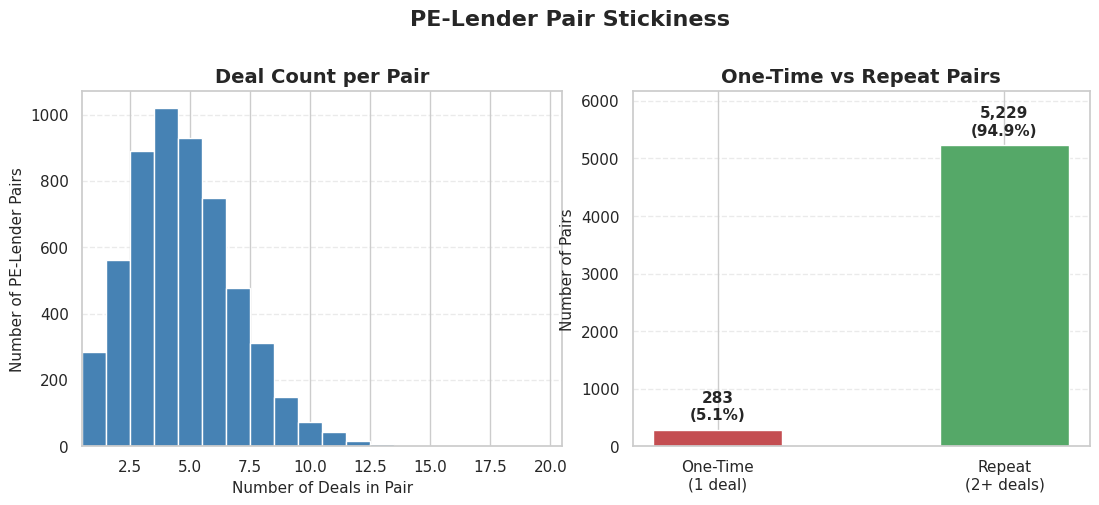

Saved figure9_pair_stickiness.png


In [163]:
# Figure 9 -- Distribution of deals per PE-lender pair (stickiness)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------
# Load data
# ---------------------------------------------------

try:
    pair_stick = pd.read_csv('pair_stickiness_summary.csv')
except FileNotFoundError:
    pair_stick = pair_df.copy()

# ---------------------------------------------------
# Create figure
# ---------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 4.8),
    gridspec_kw={'width_ratios': [1.05, 1]}
)

# ===================================================
# Figure 9a -- Histogram
# ===================================================

hist_data = pair_stick['deal_count'].clip(upper=20)

axes[0].hist(
    hist_data,
    bins=np.arange(1, 22) - 0.5,
    color='steelblue',
    edgecolor='white'
)

axes[0].set_xlim(0.5, 20.5)

axes[0].set_xlabel(
    'Number of Deals in Pair',
    fontsize=11
)

axes[0].set_ylabel(
    'Number of PE-Lender Pairs',
    fontsize=11
)

axes[0].set_title(
    'Deal Count per Pair',
    fontsize=14,
    fontweight='bold'
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

axes[0].set_axisbelow(True)

# ===================================================
# Figure 9b -- One-time vs Repeat
# ===================================================

repeat_counts = pair_stick['repeat_pair'].value_counts().sort_index()

one_time = repeat_counts.get(0, 0)
repeat = repeat_counts.get(1, 0)

labels = ['One-Time\n(1 deal)', 'Repeat\n(2+ deals)']
values = [one_time, repeat]

colors = ['#C44E52', '#55A868']

bars = axes[1].bar(
    labels,
    values,
    color=colors,
    edgecolor='white',
    width=0.45
)

# Better top spacing
ymax = max(values) * 1.18
axes[1].set_ylim(0, ymax)

# Add labels above bars
for bar, val in zip(bars, values):

    pct = (val / len(pair_stick)) * 100

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + ymax * 0.02,
        f'{val:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_ylabel(
    'Number of Pairs',
    fontsize=11
)

axes[1].set_title(
    'One-Time vs Repeat Pairs',
    fontsize=14,
    fontweight='bold'
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

axes[1].set_axisbelow(True)

# ===================================================
# Overall formatting
# ===================================================

fig.suptitle(
    'PE-Lender Pair Stickiness',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# Improve spacing between subplots
plt.subplots_adjust(
    wspace=0.15,
    top=0.85
)

# Save figure
plt.savefig(
    'figure9_pair_stickiness.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print('Saved figure9_pair_stickiness.png')

### Figure 10 -- Time Between Consecutive Deals in a Pair (Section 6.3)

Shows the distribution of inter-deal gaps. Feeds directly from `pair_time_gaps.csv`.

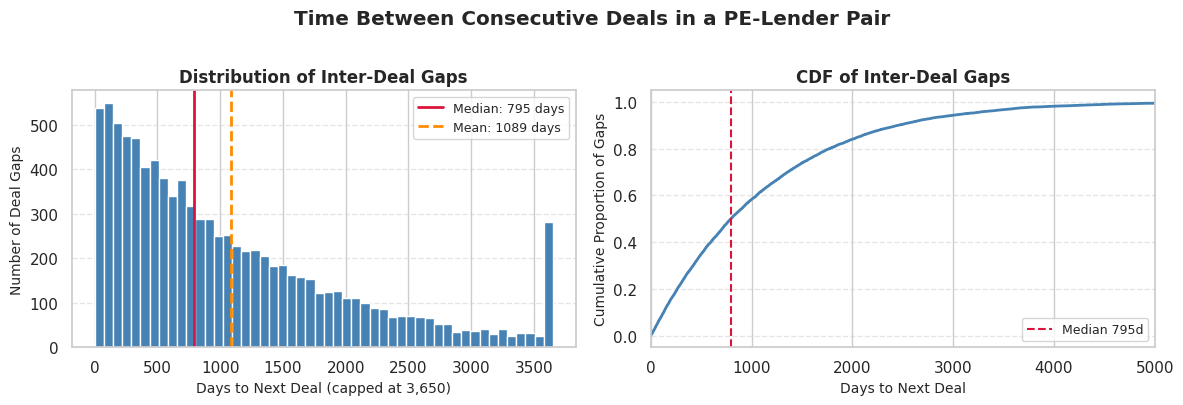

Saved figure10_time_gaps.png


In [164]:
# Figure 10 -- Time-to-next-deal distribution within pairs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    gap_data = pd.read_csv('pair_time_gaps.csv')
except FileNotFoundError:
    gap_data = gap_df.copy()

days = gap_data['gap_days'].dropna()
days_clip = days.clip(upper=3650)  # cap at 10 years for display

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
axes[0].hist(days_clip, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(days.median(), color='crimson', linewidth=2,
                label=f'Median: {days.median():.0f} days')
axes[0].axvline(days.mean(), color='darkorange', linewidth=2, linestyle='--',
                label=f'Mean: {days.mean():.0f} days')
axes[0].set_xlabel('Days to Next Deal (capped at 3,650)', fontsize=10)
axes[0].set_ylabel('Number of Deal Gaps', fontsize=10)
axes[0].set_title('Distribution of Inter-Deal Gaps', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)

# Right: cumulative proportion
sorted_days = np.sort(days.values)
cdf = np.arange(1, len(sorted_days)+1) / len(sorted_days)
axes[1].plot(sorted_days, cdf, color='steelblue', linewidth=2)
axes[1].axvline(days.median(), color='crimson', linewidth=1.5, linestyle='--',
                label=f'Median {days.median():.0f}d')
axes[1].set_xlim(0, 5000)
axes[1].set_xlabel('Days to Next Deal', fontsize=10)
axes[1].set_ylabel('Cumulative Proportion of Gaps', fontsize=10)
axes[1].set_title('CDF of Inter-Deal Gaps', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Time Between Consecutive Deals in a PE-Lender Pair', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure10_time_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure10_time_gaps.png')


In [165]:
import pandas as pd
import statsmodels.formula.api as smf

# Use the combined dataset from Step 7
outcomes = final_data.copy()

# Check relationship and outcome columns
rel_col = 'Relationship_Type'
metrics = [
    'gross_irr',
    'gross_tvm',
    'loss_multiple',
    'default_flag',
    'entry_netdebt',
    'entry_ebitda',
]

present_metrics = [c for c in metrics if c in outcomes.columns]
print("Present metrics:", present_metrics)

# Create leverage if possible
if 'entry_netdebt' in outcomes.columns and 'entry_ebitda' in outcomes.columns:
    outcomes['entry_leverage'] = outcomes['entry_netdebt'] / outcomes['entry_ebitda'].replace(0, pd.NA)

# Summary table by relationship type
summary = outcomes.groupby(rel_col)[present_metrics].agg(['mean', 'count'])
print("\n=== Outcome Summary by Relationship Type ===")
print(summary.round(3).to_string())

summary.to_csv('outcome_summary_by_relationship.csv')

# Regression examples
if 'gross_irr' in outcomes.columns:
    irr_df = outcomes.dropna(subset=['gross_irr', rel_col]).copy()
    irr_model = smf.ols(
        f'gross_irr ~ C({rel_col}, Treatment(reference="4_Unrelated"))',
        data=irr_df
    ).fit(cov_type='HC1')
    print("\n=== IRR Regression ===")
    print(irr_model.summary().tables[1].as_text())

if 'default_flag' in outcomes.columns:
    def_df = outcomes.dropna(subset=['default_flag', rel_col]).copy()
    def_df['default_flag'] = pd.to_numeric(def_df['default_flag'], errors='coerce')
    def_df = def_df.dropna(subset=['default_flag'])
    def_model = smf.logit(
        f'default_flag ~ C({rel_col}, Treatment(reference="4_Unrelated"))',
        data=def_df
    ).fit(disp=False)
    print("\n=== Default Regression ===")
    print(def_model.summary2().tables[1].to_string())

Present metrics: ['gross_irr', 'gross_tvm', 'loss_multiple', 'default_flag', 'entry_netdebt', 'entry_ebitda']

=== Outcome Summary by Relationship Type ===
                    gross_irr        gross_tvm        loss_multiple        default_flag        entry_netdebt        entry_ebitda       
                         mean  count      mean  count          mean  count         mean  count          mean  count         mean  count
Relationship_Type                                                                                                                      
1_Affiliate             0.129  13178     1.530  13178         0.009   7242        0.057   7242       363.490  13178       83.479  13178
2_Prior_Reciprocal      0.131  34166     1.537  34166         0.009  18920        0.055  18920       357.740  34166       82.457  34166
3_Reciprocal_Future     0.133   9556     1.527   9556         0.008   5339        0.050   5339       357.462   9556       82.206   9556
4_Unrelated             0.13

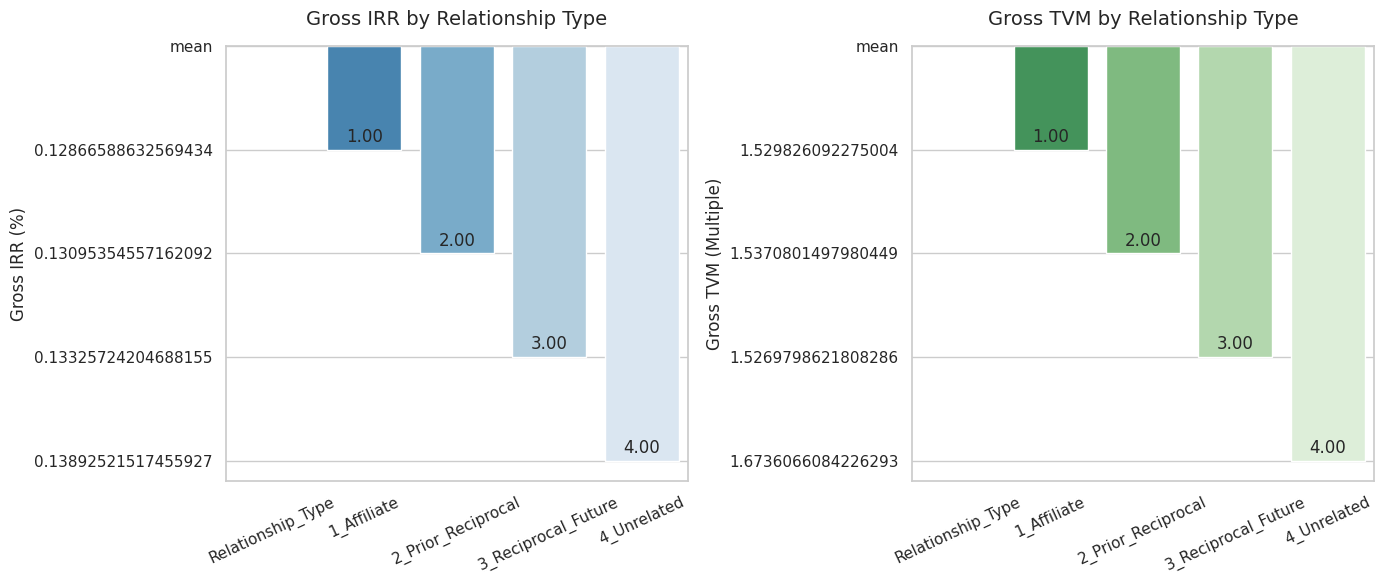

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the summary data generated by Step 8
df_outcomes = pd.read_csv('outcome_summary_by_relationship.csv')

# Rename the index column pandas created back to 'Relationship Type'
df_outcomes = df_outcomes.rename(columns={'Unnamed: 0': 'Relationship Type'})

# Set up the figure
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Gross IRR (using exact column name 'gross_irr')
sns.barplot(
    data=df_outcomes,
    x='Relationship Type',
    y='gross_irr',
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title('Gross IRR by Relationship Type', fontsize=14, pad=15)
axes[0].set_ylabel('Gross IRR (%)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

# Plot Gross TVM (using exact column name 'gross_tvm')
sns.barplot(
    data=df_outcomes,
    x='Relationship Type',
    y='gross_tvm',
    ax=axes[1],
    palette="Greens_r"
)
axes[1].set_title('Gross TVM by Relationship Type', fontsize=14, pad=15)
axes[1].set_ylabel('Gross TVM (Multiple)', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

# Add data labels
for ax in axes:
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.tight_layout()
plt.savefig('figure6_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

In [167]:
print(df_outcomes.columns)

Index(['Relationship Type', 'gross_irr', 'gross_irr.1', 'gross_tvm',
       'gross_tvm.1', 'loss_multiple', 'loss_multiple.1', 'default_flag',
       'default_flag.1', 'entry_netdebt', 'entry_netdebt.1', 'entry_ebitda',
       'entry_ebitda.1'],
      dtype='object')


## Stickiness Results Summary

**Repeat-pair model (cell above):**

The dataset contains **5,512 unique PE–lender pairs**. Describing deal counts per pair:
- Mean deals per pair: **4.71**
- **95% of pairs (5,229 out of 5,512) transact more than once** — only 283 pairs appear exactly once

This is a striking result: almost every PE–lender pairing in the dataset is a repeat relationship. One-time deals between firms are the rare exception, not the norm.

**Logit regression on repeat behaviour:**

After controlling for the year of the first deal and the initial loan spread:
- `year_centered` coefficient: **−0.32 (p < 0.001)** — pairs formed more recently are slightly less likely to have already repeated, which makes intuitive sense given less time has passed
- `first_deal_spread_log` coefficient: **+1.20 (p = 0.010)** — pairs whose first deal had a higher interest rate are *more* likely to transact again; one interpretation is that higher-spread deals signal more complex situations where a continuing relationship is more valuable

**Time-to-next-deal model:**

Among the 20,457 consecutive deal gaps within existing pairs:
- Mean gap: **1,091 days (~3 years)**
- Median gap: **794 days (~2.2 years)**
- Shortest average gaps (from the top-20 list) cluster around pairs like `opalridgevex | indigonex` (1 day apart) and `copperlinegate | cedarvale` (15 days apart)

The OLS regression on log(days to next deal) shows:
- `year_centered` coefficient: **−0.065 (p < 0.001)** — more recent pairs close their next deal faster
- `spread_log` coefficient: **−0.109 (p = 0.086)** — marginally significant negative effect; pairs with higher initial spreads tend to re-transact slightly sooner, though this effect is weak

Together, the stickiness analysis confirms that PE–lender pairings are highly persistent: once two firms start working together, the relationship almost always continues, and typically produces a follow-on transaction within about two years.


---
# Step 10 — Three-Model Regression: Isolating the Relationship Effect

This step extends the single OLS model from Step 6 into a three-model specification that progressively rules out alternative explanations for the pricing gap.

**This step runs after Step 7** so that `final_data` (the Atlas–Summit merged dataset) is available for borrower controls — `entry_ebitda` and `entry_netdebt` come from Summit.

A single model with only year fixed effects cannot rule out two alternatives:
1. **Borrower selection** — relationship lenders may choose smaller or safer companies, which command lower spreads regardless of the relationship.
2. **Lender-specific pricing** — some lenders price lower by policy; if they also happen to be in reciprocal relationships the coefficient is spurious.

Three nested models isolate the relationship effect:

| Model | Controls added | What it rules out |
|---|---|---|
| **Model 1** | Year FE only | Market-wide rate movements |
| **Model 2** | + log(EBITDA), entry leverage, log(deal size) | Borrower size and credit risk |
| **Model 3** | + lender (`PC_Umbrella`) FE | All lender-specific pricing policies |

All models use **HC1 heteroskedasticity-robust standard errors**. Reference group: `4_Unrelated`.


In [168]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Build regression base ────────────────────────────────────────────────
# This cell runs after Step 7, so final_data (Atlas + Summit merged) is
# available. We pull borrower controls from it directly.
reg_base = pe_backed_debt.dropna(subset=['LoanSpreadBps', 'Debt_Year']).copy()
print(f"Base rows (have spread + year): {len(reg_base):,}")

# ── Borrower controls from Summit (via final_data) ───────────────────────
#
# final_data is the Atlas–Summit merged dataset from Step 7.
# We aggregate to one median value per company to handle
# companies that appear in multiple Summit fund records.
#
# Controls:
#   entry_ebitda   → company size proxy (larger firms borrow cheaper)
#   entry_netdebt  → used to compute entry leverage (net debt / EBITDA)
#   DealSize       → loan size from Atlas (volume discount / deal complexity)

summit_controls = (
    final_data
    .groupby('Clean_Company')[['entry_ebitda', 'entry_netdebt']]
    .median()
    .reset_index()
)
reg_data = reg_base.merge(summit_controls, on='Clean_Company', how='left')

summit_match_pct = reg_data['entry_ebitda'].notna().mean() * 100
print(f"Summit controls matched      : {summit_match_pct:.1f}% of regression rows")

# ── Construct control variables ───────────────────────────────────────────
reg_data['log_ebitda'] = np.log1p(
    reg_data['entry_ebitda'].abs().clip(lower=0)
)
reg_data['entry_leverage'] = (
    reg_data['entry_netdebt'] /
    reg_data['entry_ebitda'].replace(0, np.nan)
)
if 'DealSize' in reg_data.columns:
    reg_data['log_dealsize'] = np.log1p(
        pd.to_numeric(reg_data['DealSize'], errors='coerce').clip(lower=0)
    )
else:
    reg_data['log_dealsize'] = np.nan

# Winsorise at 1st / 99th percentile to limit outlier influence
for col in ['log_ebitda', 'entry_leverage', 'log_dealsize']:
    lo = reg_data[col].quantile(0.01)
    hi = reg_data[col].quantile(0.99)
    reg_data[col] = reg_data[col].clip(lower=lo, upper=hi)

# ── Report sample sizes ───────────────────────────────────────────────────
n_m1 = int(reg_data['LoanSpreadBps'].notna().sum())
ctrl_ok = reg_data[['entry_leverage', 'log_ebitda']].notna().all(axis=1)
n_m2 = int(reg_data.loc[ctrl_ok, 'LoanSpreadBps'].notna().sum())
lfe_ok = ctrl_ok & reg_data['PC_Umbrella'].notna()
n_m3 = int(reg_data.loc[lfe_ok, 'LoanSpreadBps'].notna().sum())

print(f"Model 1 sample (Year FE only)        : {n_m1:,}")
print(f"Model 2 sample (+ borrower controls) : {n_m2:,}")
print(f"Model 3 sample (+ lender FE)         : {n_m3:,}")


Base rows (have spread + year): 14,614
Summit controls matched      : 96.0% of regression rows
Model 1 sample (Year FE only)        : 14,614
Model 2 sample (+ borrower controls) : 14,025
Model 3 sample (+ lender FE)         : 14,025


In [169]:
print(reg_data.columns.tolist())

['CompanyID', 'CompanyName', 'Debt_DealID', 'Debt_Date', 'DealType', 'CreditProviderName', 'LoanSpreadBps', 'CompanyName_spell', 'EquitySponsorName', 'Spell_Start_Date', 'Spell_End_Date', 'Buyout_DealID', 'Spell_Year', 'PE_Clean', 'PC_Clean', 'PE_Umbrella', 'PC_Umbrella', 'Is_Affiliate', 'Is_Cross_Deal', 'Is_Reciprocal', 'Is_Prior_Reciprocal', 'Relationship_Type', 'Debt_Year', 'Clean_Company', 'entry_ebitda', 'entry_netdebt', 'log_ebitda', 'entry_leverage', 'log_dealsize']


In [170]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# =========================================================
# Variable definitions
# =========================================================

REL  = 'C(Relationship_Type, Treatment(reference="4_Unrelated"))'
YEAR = 'C(Debt_Year)'
CTRL = 'log_ebitda + entry_leverage'
LFE  = 'C(PC_Umbrella)'

# =========================================================
# Clean regression data
# =========================================================

reg_data = reg_data.copy()

# Replace inf values with NaN
reg_data = reg_data.replace([np.inf, -np.inf], np.nan)

# Check key variables
required_vars = [
    'LoanSpreadBps',
    'Relationship_Type',
    'Debt_Year',
    'log_ebitda',
    'entry_leverage'
]

print('\n=== Missing value check ===')
print(reg_data[required_vars].isna().sum())

# =========================================================
# Model 1 -- Year FE only
# =========================================================

m1_data = reg_data.dropna(
    subset=[
        'LoanSpreadBps',
        'Relationship_Type',
        'Debt_Year'
    ]
).copy()

print(f'\nModel 1 sample size: {len(m1_data):,}')

m1 = smf.ols(
    f'LoanSpreadBps ~ {REL} + {YEAR}',
    data=m1_data
).fit(cov_type='HC1')

# =========================================================
# Model 2 -- Add borrower controls
# =========================================================

m2_data = reg_data.dropna(
    subset=[
        'LoanSpreadBps',
        'Relationship_Type',
        'Debt_Year',
        'log_ebitda',
        'entry_leverage'
    ]
).copy()

print(f'Model 2 sample size: {len(m2_data):,}')

# Stop if no data remains
if len(m2_data) == 0:
    raise ValueError(
        'Model 2 dataset is empty after dropping missing values.'
    )

m2 = smf.ols(
    f'LoanSpreadBps ~ {REL} + {YEAR} + {CTRL}',
    data=m2_data
).fit(cov_type='HC1')

# =========================================================
# Model 3 -- Add lender fixed effects
# =========================================================

m3_data = m2_data.dropna(subset=['PC_Umbrella']).copy()

# Remove singleton lenders
lender_counts = m3_data['PC_Umbrella'].value_counts()

valid_lenders = lender_counts[lender_counts > 1].index

m3_data = m3_data[
    m3_data['PC_Umbrella'].isin(valid_lenders)
].copy()

print(f'Model 3 sample size: {len(m3_data):,}')
print(f'Unique lenders: {m3_data["PC_Umbrella"].nunique():,}')

if len(m3_data) == 0:
    raise ValueError(
        'Model 3 dataset is empty after removing singleton lenders.'
    )

m3 = smf.ols(
    f'LoanSpreadBps ~ {REL} + {YEAR} + {CTRL} + {LFE}',
    data=m3_data
).fit(cov_type='HC1')

# =========================================================
# Model statistics
# =========================================================

print('\n=== Model fit statistics ===')

for label, model in [
    ('Model 1 (Year FE only)', m1),
    ('Model 2 (+ borrower controls)', m2),
    ('Model 3 (+ lender FE)', m3)
]:
    print(
        f'{label}: '
        f'N={int(model.nobs):,} | '
        f'R²={model.rsquared:.4f} | '
        f'Adj-R²={model.rsquared_adj:.4f}'
    )

# Store models
models_list = [m1, m2, m3]


=== Missing value check ===
LoanSpreadBps          0
Relationship_Type      0
Debt_Year              0
log_ebitda           589
entry_leverage       589
dtype: int64

Model 1 sample size: 14,614
Model 2 sample size: 14,025
Model 3 sample size: 14,025
Unique lenders: 88

=== Model fit statistics ===
Model 1 (Year FE only): N=14,614 | R²=0.1056 | Adj-R²=0.1039
Model 2 (+ borrower controls): N=14,025 | R²=0.1046 | Adj-R²=0.1028
Model 3 (+ lender FE): N=14,025 | R²=0.1105 | Adj-R²=0.1032


In [171]:
# =========================================================
# Pretty regression table printer
# =========================================================

# ---------------------------------------------------------
# Helper: find parameter containing key string
# ---------------------------------------------------------

def _find_term(model, key):

    for p in model.params.index:
        if key in p:
            return p

    return None


# ---------------------------------------------------------
# Variables to display
# ---------------------------------------------------------

REL_TERMS = {
    '1_Affiliate':         'Affiliate',
    '2_Prior_Reciprocal':  'Prior-reciprocal',
    '3_Reciprocal_Future': 'Reciprocal (future)',
}

# Remove log_dealsize because it is not in model now
CTRL_TERMS = {
    'log_ebitda':     'log(Entry EBITDA)',
    'entry_leverage': 'Entry leverage',
}


# ---------------------------------------------------------
# Formatting helper
# ---------------------------------------------------------

def fmt(model, key):

    term = _find_term(model, key)

    if term is None:
        return '—', ''

    pval = model.pvalues[term]

    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = ''

    coef = f'{model.params[term]:+.1f}{sig}'
    se   = f'({model.bse[term]:.1f})'

    return coef, se


# =========================================================
# Print formatted regression table
# =========================================================

SEP = '-' * 86

print('\n')
print('=' * 86)

print('Table 3 — OLS: Loan Spread (bps) on Relationship Type')

print(
    'Reference category: 4_Unrelated '
    '| HC1 robust standard errors in parentheses'
)

print('=' * 86)

# ---------------------------------------------------------
# Column headers
# ---------------------------------------------------------

print(
    f"{'Variable':<28}"
    f"{'Model 1':>14}"
    f"{'Model 2':>14}"
    f"{'Model 3':>14}"
)

print(SEP)

# =========================================================
# Relationship variables
# =========================================================

for key, label in REL_TERMS.items():

    c1, s1 = fmt(m1, key)
    c2, s2 = fmt(m2, key)
    c3, s3 = fmt(m3, key)

    print(
        f"{label:<28}"
        f"{c1:>14}"
        f"{c2:>14}"
        f"{c3:>14}"
    )

    print(
        f"{'':<28}"
        f"{s1:>14}"
        f"{s2:>14}"
        f"{s3:>14}"
    )

# =========================================================
# Control variables
# =========================================================

print(SEP)

for key, label in CTRL_TERMS.items():

    c1, s1 = fmt(m1, key)
    c2, s2 = fmt(m2, key)
    c3, s3 = fmt(m3, key)

    print(
        f"{label:<28}"
        f"{c1:>14}"
        f"{c2:>14}"
        f"{c3:>14}"
    )

    print(
        f"{'':<28}"
        f"{s1:>14}"
        f"{s2:>14}"
        f"{s3:>14}"
    )

# =========================================================
# Model summary rows
# =========================================================

print(SEP)

summary_rows = [
    (
        'Year FE',
        'Yes',
        'Yes',
        'Yes'
    ),
    (
        'Borrower controls',
        'No',
        'Yes',
        'Yes'
    ),
    (
        'Lender FE',
        'No',
        'No',
        'Yes'
    ),
    (
        'Observations',
        f'{int(m1.nobs):,}',
        f'{int(m2.nobs):,}',
        f'{int(m3.nobs):,}'
    ),
    (
        'R²',
        f'{m1.rsquared:.3f}',
        f'{m2.rsquared:.3f}',
        f'{m3.rsquared:.3f}'
    ),
    (
        'Adj. R²',
        f'{m1.rsquared_adj:.3f}',
        f'{m2.rsquared_adj:.3f}',
        f'{m3.rsquared_adj:.3f}'
    )
]

for row in summary_rows:

    label, v1, v2, v3 = row

    print(
        f"{label:<28}"
        f"{v1:>14}"
        f"{v2:>14}"
        f"{v3:>14}"
    )

print('=' * 86)

print(
    'Significance codes: '
    '*** p<0.001  '
    '** p<0.01  '
    '* p<0.05'
)



Table 3 — OLS: Loan Spread (bps) on Relationship Type
Reference category: 4_Unrelated | HC1 robust standard errors in parentheses
Variable                           Model 1       Model 2       Model 3
--------------------------------------------------------------------------------------
Affiliate                         -55.8***      -55.7***      -42.7***
                                     (2.5)         (2.5)         (9.2)
Prior-reciprocal                  -15.5***      -16.0***          -2.8
                                     (2.0)         (2.1)         (9.1)
Reciprocal (future)               -19.8***      -19.5***          -7.0
                                     (2.9)         (3.0)         (9.4)
--------------------------------------------------------------------------------------
log(Entry EBITDA)                        —          +1.7          +1.7
                                                   (0.9)         (0.9)
Entry leverage                           —          +0.

### Three-Model OLS Figure (Section 3.2)

Produces the publication-ready figure with dot-and-whisker plot (left) and coefficient table (right). Also exports `table3_three_model_ols.csv` for the memo.


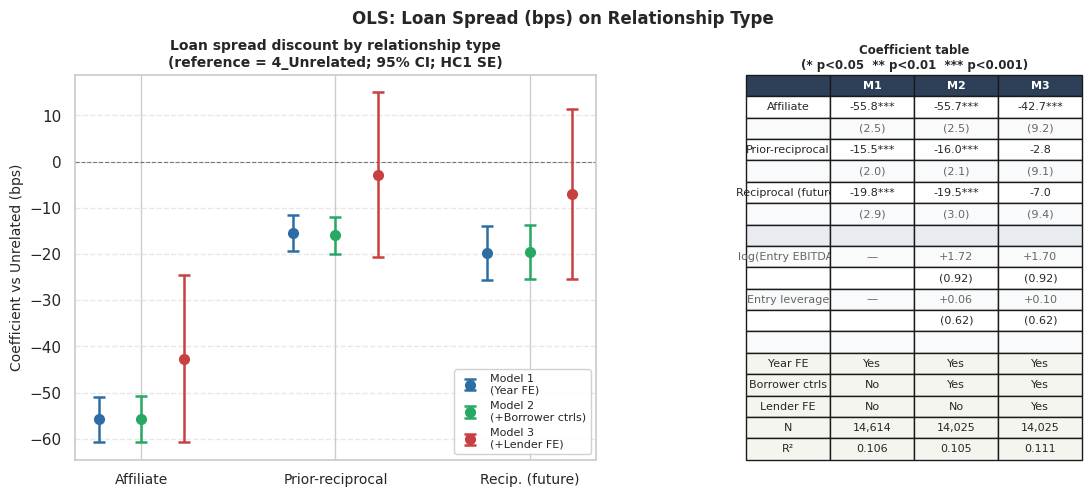

Saved figure_table3_ols_results.png
Saved table3_three_model_ols.csv


In [172]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

REL_LABELS  = ['Affiliate', 'Prior-reciprocal', 'Recip. (future)']
REL_KEYS    = list(REL_TERMS.keys())
MODEL_NAMES = ['Model 1\n(Year FE)', 'Model 2\n(+Borrower ctrls)', 'Model 3\n(+Lender FE)']
COLORS      = ['#2E6DA4', '#27A864', '#C94040']
OFFSETS     = [-0.22, 0.0, 0.22]

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.55, 1], wspace=0.35)

# ── LEFT: dot-and-whisker ────────────────────────────────────────────────
ax_left = fig.add_subplot(gs[0])
x_ticks = np.arange(len(REL_LABELS))

for m_idx, (m, col, off) in enumerate(zip(models_list, COLORS, OFFSETS)):
    coefs, lowers, uppers = [], [], []
    for key in REL_KEYS:
        term = _find_term(m, key)
        if term:
            ci = m.conf_int()
            coefs.append(m.params[term])
            lowers.append(ci.loc[term, 0])
            uppers.append(ci.loc[term, 1])
        else:
            coefs.append(np.nan); lowers.append(np.nan); uppers.append(np.nan)

    yerr = np.array([[c - lo for c, lo in zip(coefs, lowers)],
                     [hi - c for c, hi in zip(coefs, uppers)]])
    ax_left.errorbar(
        x_ticks + off, coefs, yerr=yerr,
        fmt='o', color=col, ecolor=col,
        elinewidth=1.8, capsize=4, capthick=1.8,
        markersize=7, label=MODEL_NAMES[m_idx], zorder=3 + m_idx,
    )

ax_left.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax_left.set_xticks(x_ticks)
ax_left.set_xticklabels(REL_LABELS, fontsize=10)
ax_left.set_ylabel('Coefficient vs Unrelated (bps)', fontsize=10)
ax_left.set_title(
    'Loan spread discount by relationship type\n(reference = 4_Unrelated; 95% CI; HC1 SE)',
    fontsize=10, fontweight='bold')
ax_left.legend(fontsize=8, framealpha=0.9)
ax_left.yaxis.grid(True, linestyle='--', alpha=0.45)
ax_left.set_axisbelow(True)

# ── RIGHT: coefficient table ─────────────────────────────────────────────
ax_right = fig.add_subplot(gs[1])
ax_right.axis('off')

col_headers = ['', 'M1', 'M2', 'M3']
table_data  = []

for key, label in REL_TERMS.items():
    row_c, row_s = [label], ['']
    for m in models_list:
        term = _find_term(m, key)
        if term:
            sig = ('***' if m.pvalues[term] < 0.001 else
                   '**'  if m.pvalues[term] < 0.01  else
                   '*'   if m.pvalues[term] < 0.05  else '')
            row_c.append(f"{m.params[term]:+.1f}{sig}")
            row_s.append(f"({m.bse[term]:.1f})")
        else:
            row_c.append('—'); row_s.append('')
    table_data += [row_c, row_s]

table_data.append(['']*4)

for key, label in CTRL_TERMS.items():
    row_c, row_s = [label], ['']
    for m in models_list:
        term = _find_term(m, key)
        if term:
            sig = ('***' if m.pvalues[term] < 0.001 else
                   '**'  if m.pvalues[term] < 0.01  else
                   '*'   if m.pvalues[term] < 0.05  else '')
            row_c.append(f"{m.params[term]:+.2f}{sig}")
            row_s.append(f"({m.bse[term]:.2f})")
        else:
            row_c.append('—'); row_s.append('')
    table_data += [row_c, row_s]

table_data.append(['']*4)
for row_label, v1, v2, v3 in [
    ('Year FE',        'Yes',                   'Yes',                   'Yes'),
    ('Borrower ctrls', 'No',                    'Yes',                   'Yes'),
    ('Lender FE',      'No',                    'No',                    'Yes'),
    ('N',              f'{int(m1.nobs):,}',     f'{int(m2.nobs):,}',     f'{int(m3.nobs):,}'),
    ('R²',             f'{m1.rsquared:.3f}',    f'{m2.rsquared:.3f}',    f'{m3.rsquared:.3f}'),
]:
    table_data.append([row_label, v1, v2, v3])

tbl = ax_right.table(
    cellText=table_data, colLabels=col_headers,
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for j in range(4):
    tbl[(0, j)].set_facecolor('#2E4057')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
# SE rows lighter
se_rows = [2, 4, 6, 8, 10, 12]
for i in range(1, len(table_data) + 1):
    for j in range(4):
        cell = tbl[(i, j)]
        if i in se_rows:
            cell.set_facecolor('#F9FAFB')
            cell.set_text_props(color='#666666')
        elif table_data[i-1] == ['']*4:
            cell.set_facecolor('#E8EBF0')
        elif i > len(table_data) - 5:
            cell.set_facecolor('#F5F5F0')

ax_right.set_title('Coefficient table\n(* p<0.05  ** p<0.01  *** p<0.001)',
                    fontsize=8.5, fontweight='bold', pad=4)
plt.suptitle('OLS: Loan Spread (bps) on Relationship Type',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig('figure_table3_ols_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figure_table3_ols_results.png')

# ── Export CSV ────────────────────────────────────────────────────────────
csv_rows = []
for key, label in REL_TERMS.items():
    for i, m in enumerate(models_list, start=1):
        term = _find_term(m, key)
        if term:
            ci = m.conf_int()
            csv_rows.append({
                'Model': f'Model {i}', 'Variable': label,
                'Coef': round(m.params[term], 3),
                'SE':   round(m.bse[term], 3),
                'p_value': round(m.pvalues[term], 4),
                'CI_lower': round(ci.loc[term, 0], 3),
                'CI_upper': round(ci.loc[term, 1], 3),
            })
pd.DataFrame(csv_rows).to_csv('table3_three_model_ols.csv', index=False)
print('Saved table3_three_model_ols.csv')


In [173]:
# ── Coefficient stability: how much of the raw gap survives controls? ────
print('=== Coefficient Stability Check ===')
print('How much of the Model 1 discount remains after adding controls?\n')
print(f"{'Relationship':<22} {'M1':>8} {'M2':>8} {'M3':>8}  {'M3 as % of M1':>14}")
print('-' * 62)

for key, label in REL_TERMS.items():
    vals = []
    for m in models_list:
        term = _find_term(m, key)
        vals.append(m.params[term] if term else np.nan)
    pct = (vals[2] / vals[0] * 100) if (vals[0] and not np.isnan(vals[2])) else np.nan
    print(f"{label:<22} {vals[0]:>+7.1f}  {vals[1]:>+7.1f}  {vals[2]:>+7.1f}  {pct:>12.1f}%")

print()
print('Interpretation:')
print('  M3 coeff ≈ M1 coeff  →  pricing gap is a genuine relationship effect')
print('  M3 coeff → 0         →  gap is explained by borrower risk or lender style')


=== Coefficient Stability Check ===
How much of the Model 1 discount remains after adding controls?

Relationship                 M1       M2       M3   M3 as % of M1
--------------------------------------------------------------
Affiliate                -55.8    -55.7    -42.7          76.6%
Prior-reciprocal         -15.5    -16.0     -2.8          18.3%
Reciprocal (future)      -19.8    -19.5     -7.0          35.3%

Interpretation:
  M3 coeff ≈ M1 coeff  →  pricing gap is a genuine relationship effect
  M3 coeff → 0         →  gap is explained by borrower risk or lender style


In [174]:
# ============================================================
# EXPORT: package figures and tables into two zip files
# Run this cell after all figure/table cells have executed.
# ============================================================
import zipfile, os

FIGURE_FILES = [
    "figure1_deal_type_dist.png",
    "figure2_spell_starts_by_year.png",
    "figure3_spread_boxplot.png",
    "figure4_spread_over_time.png",
    "figure5_sponsor_lender_heatmap.png",
    "figure6_outcomes.png",
    "figure7_entry_leverage.png",
    "figure8_reciprocal_share.png",
    "figure9_pair_stickiness.png",
    "figure10_time_gaps.png",
    "figure_table3_ols_results.png"
]

TABLE_FILES = [
    "figure_table1_funnel.png",
    "figure_table2_spread_descriptives.png",
    "figure_table3_ols_results.png",
    "figure_table4_outcomes.png",
]

def make_zip(zip_name, file_list):
    found, missing = [], []
    for f in file_list:
        (found if os.path.exists(f) else missing).append(f)
    if missing:
        print(f"  WARNING: {len(missing)} file(s) not found and will be skipped: {missing}")
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in found:
            zf.write(f)
    print(f"  Created {zip_name} ({len(found)} files, {os.path.getsize(zip_name):,} bytes)")
    return found

print("Packaging figures...")
make_zip("figures.zip", FIGURE_FILES)

print("Packaging tables...")
make_zip("tables.zip", TABLE_FILES)

print("\nDone. Download figures.zip and tables.zip from the Files panel.")


Packaging figures...
  Created figures.zip (11 files, 1,198,449 bytes)
Packaging tables...
  Created tables.zip (4 files, 266,280 bytes)

Done. Download figures.zip and tables.zip from the Files panel.


---
# Output Files

| File | Contents |
|---|---|
| `atlas_parsed.parquet` | Atlas (315,238 rows) with verified column types and `EffectiveDate` |
| `summit_parsed.parquet` | Summit (48,317 rows) with verified column types |
| `match_review_file.csv` | 2,317 approximate match candidates with ACCEPT/REJECT decisions |
| `match_review_file_resolved.csv` | Final resolved version used by Step 7-G |
| `outcome_summary_by_relationship.csv` | Mean entry and outcome metrics by relationship type |
| `pair_stickiness_summary.csv` | One row per PE–lender pair with deal count and repeat flag |
| `pair_time_gaps.csv` | One row per consecutive deal gap within a pair, with days-to-next-deal |
|`figures.zip`| Collection of all the figures|
|`tables.zip`| Colection of all the output tables|
